# STAT3612: Multimodal Brain Tumor Classification — Full Pipeline

This notebook implements the **three-stage pipeline** described in our proposal:

| Section | Proposal Stage | Content |
|---|---|---|
| **0. Setup & EDA** | Preliminary Findings | Environment, data loading, EDA findings (class imbalance, missing data, multimodal incompleteness) |
| **1. Feature Engineering** | Data Processing | Load & encode all 4 modalities; PCA; standardize |
| **2. Single-Modality Baselines** | Stage 1 | Independent classifiers per modality to understand individual contributions |
| **3. Multimodal Fusion** | Stage 2 | Early fusion (concatenated features) and late fusion (voting/stacking) |
| **4. Optimization** | Stage 3 | Feature selection, PCA sweep, SVM/XGB tuning (Section 4.1) |
| **5. Model Analysis** | Analysis Plan | Model comparison, modality ablation, interpretability |
| **6. Kaggle Submission** | — | Generate final submission file |

**Primary evaluation metric**: **Macro-F1** (aligned with Kaggle leaderboard F1 scoring)  
**Secondary metrics**: Weighted-F1, Accuracy, Per-class Precision/Recall/F1  
**5-class target**: Glioma, Meningioma, Brain Metastase Tumour, Tumors of the sellar region, Pineal tumour and Choroid plexus tumour

---
# 0. Setup & Exploratory Data Analysis

## 0.1 Environment

In [20]:
import sklearn, imblearn
print(sklearn.__version__, imblearn.__version__)

1.7.2 0.14.1


In [21]:
import copy
import json, os, warnings
from collections import Counter
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Install PyTorch if not already installed
import sys
import subprocess

# Check if torch is installed
try:
    import torch
    print(f"PyTorch version {torch.__version__} is already installed")
except ImportError:
    print("Installing PyTorch...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch"])
    import torch
    print(f"PyTorch version {torch.__version__} has been installed")



import torch
import xgboost as xgb
from torch import nn
from torch.utils.data import DataLoader, Dataset

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               VotingClassifier, StackingClassifier)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import StratifiedKFold, cross_val_score

sns.set_theme(style='whitegrid')
warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

def _find_train_val_root() -> Path:
    """Locate folder containing train.json + val.json (dataset/kaggle-dataset or ./kaggle-dataset)."""
    names = ('dataset/kaggle-dataset', 'kaggle-dataset')

    def _try_pair(base: Path) -> Path | None:
        base = base.resolve()
        for name in names:
            p = base / name
            if (p / 'train.json').is_file() and (p / 'val.json').is_file():
                return p
        if (base / 'train.json').is_file() and (base / 'val.json').is_file():
            return base
        return None

    seen: set[Path] = set()
    search_order: list[Path] = []

    for key in ('STAT3612_TRAIN_VAL_DIR', 'STAT3612_DATA_ROOT', 'KAGGLE_DATA_ROOT'):
        v = os.environ.get(key, '').strip()
        if v:
            search_order.append(Path(v).expanduser())

    search_order.append(Path.cwd())
    kin = Path('/kaggle/input')
    if kin.is_dir():
        for sub in sorted(kin.iterdir()):
            if sub.is_dir():
                search_order.append(sub)

    for start in search_order:
        try:
            start = start.resolve()
        except OSError:
            continue
        for d in [start, *start.parents]:
            if d in seen:
                continue
            seen.add(d)
            hit = _try_pair(d)
            if hit is not None:
                return hit

    cwd = Path.cwd()
    raise FileNotFoundError(
        'Cannot find train.json and val.json.\n'
        f'  cwd = {cwd}\n'
        '  Fix: (1) os.chdir("/path/to/STAT3612-Amateur-Neuro-Team") before this cell, or\n'
        '  (2) set env STAT3612_TRAIN_VAL_DIR to the folder containing train.json and val.json.\n'
        '  See dataset/README.md.'
    )


def _find_test_root(train_val: Path) -> Path:
    """Monolithic layout: test.json next to train. Split layout: sibling new_test/test.json."""
    if (train_val / 'test.json').is_file():
        return train_val.resolve()
    cand = train_val.parent / 'new_test' / 'test.json'
    if cand.is_file():
        return cand.parent.resolve()
    raise FileNotFoundError(
        f'Cannot find test.json next to {train_val} or at {cand}. See dataset/README.md.'
    )


TRAIN_VAL_ROOT = _find_train_val_root()
TEST_ROOT = _find_test_root(TRAIN_VAL_ROOT)
BASE_DIR = str(TRAIN_VAL_ROOT)
print('TRAIN_VAL_ROOT =', TRAIN_VAL_ROOT)
print('TEST_ROOT =', TEST_ROOT)

PyTorch version 2.5.1 is already installed
TRAIN_VAL_ROOT = /Users/qinzilan/Desktop/3612/dataset/kaggle-dataset
TEST_ROOT = /Users/qinzilan/Desktop/3612/dataset/new_test


## 0.2 Load Metadata

In [22]:
with open(TRAIN_VAL_ROOT / 'train.json') as f:
    train_meta = json.load(f)
with open(TRAIN_VAL_ROOT / 'val.json') as f:
    val_meta = json.load(f)
with open(TEST_ROOT / 'test.json') as f:
    test_meta = json.load(f)

print(f'Splits — Train: {len(train_meta)}, Val: {len(val_meta)}, Test: {len(test_meta)}')

train_labels = {k: v['Overall_class'] for k, v in train_meta.items()}
val_labels   = {k: v['Overall_class'] for k, v in val_meta.items()}

Splits — Train: 1983, Val: 283, Test: 378


## 0.3 EDA: Class Imbalance (~40:1)

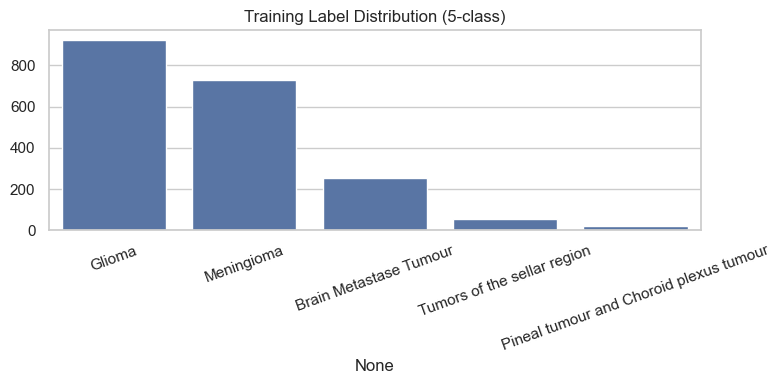

Class frequencies:
  Glioma: 924 (46.6%)
  Meningioma: 728 (36.7%)
  Brain Metastase Tumour: 252 (12.7%)
  Tumors of the sellar region: 56 (2.8%)
  Pineal tumour and Choroid plexus tumour: 23 (1.2%)

Imbalance ratio (max/min): 40:1


In [23]:
label_counts = pd.Series(Counter(train_labels.values())).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=label_counts.index, y=label_counts.values, ax=ax)
ax.set_title('Training Label Distribution (5-class)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

print('Class frequencies:')
for cls, cnt in label_counts.items():
    print(f'  {cls}: {cnt} ({cnt/len(train_labels)*100:.1f}%)')
print(f'\nImbalance ratio (max/min): {label_counts.max()/label_counts.min():.0f}:1')

## 0.4 EDA: Multimodal Incompleteness (~20% missing 1 modality)

In [24]:
MODALITIES = ['ax_t1', 'ax_t1c', 'ax_t2', 'ax_t2f']

for split_name, meta in [('train', train_meta), ('val', val_meta), ('test', test_meta)]:
    n_paths = [len(v.get('image_path', [])) for v in meta.values()]
    counts = Counter(n_paths)
    total = len(meta)
    print(f'[{split_name}] modality completeness: ', end='')
    for k in sorted(counts):
        print(f'{k}-mod={counts[k]} ({counts[k]/total*100:.1f}%)  ', end='')
    print()

[train] modality completeness: 3-mod=390 (19.7%)  4-mod=1593 (80.3%)  
[val] modality completeness: 3-mod=61 (21.6%)  4-mod=222 (78.4%)  
[test] modality completeness: 1-mod=10 (2.6%)  2-mod=9 (2.4%)  3-mod=81 (21.4%)  4-mod=278 (73.5%)  


## 0.5 EDA: Missing Demographics (JSON ~70% vs CSV ~0%)

In [25]:
def _clean_cols(df):
    df.columns = [str(c).replace(chr(0xFEFF), '').strip() for c in df.columns]
    return df

clin_train = _clean_cols(pd.read_csv(os.path.join(BASE_DIR, 'clinical_information', 'train_patient_info.csv')))

json_age_missing = sum(1 for v in train_meta.values() if not v.get('Age'))
json_sex_missing = sum(1 for v in train_meta.values() if not v.get('Sex'))
clin_age_missing = clin_train['Age'].isna().sum()
clin_sex_missing = clin_train['Sex'].isna().sum()

print(f'JSON  Age missing: {json_age_missing}/{len(train_meta)} ({json_age_missing/len(train_meta)*100:.1f}%)')
print(f'JSON  Sex missing: {json_sex_missing}/{len(train_meta)} ({json_sex_missing/len(train_meta)*100:.1f}%)')
print(f'CSV   Age missing: {clin_age_missing}/{len(clin_train)} ({clin_age_missing/len(clin_train)*100:.1f}%)')
print(f'CSV   Sex missing: {clin_sex_missing}/{len(clin_train)} ({clin_sex_missing/len(clin_train)*100:.1f}%)')
print('\n=> Clinical CSV is the preferred source for demographics.')

JSON  Age missing: 1380/1983 (69.6%)
JSON  Sex missing: 1380/1983 (69.6%)
CSV   Age missing: 1384/1983 (69.8%)
CSV   Sex missing: 0/1983 (0.0%)

=> Clinical CSV is the preferred source for demographics.


## 0.6 EDA: Radiomics Feature Correlation

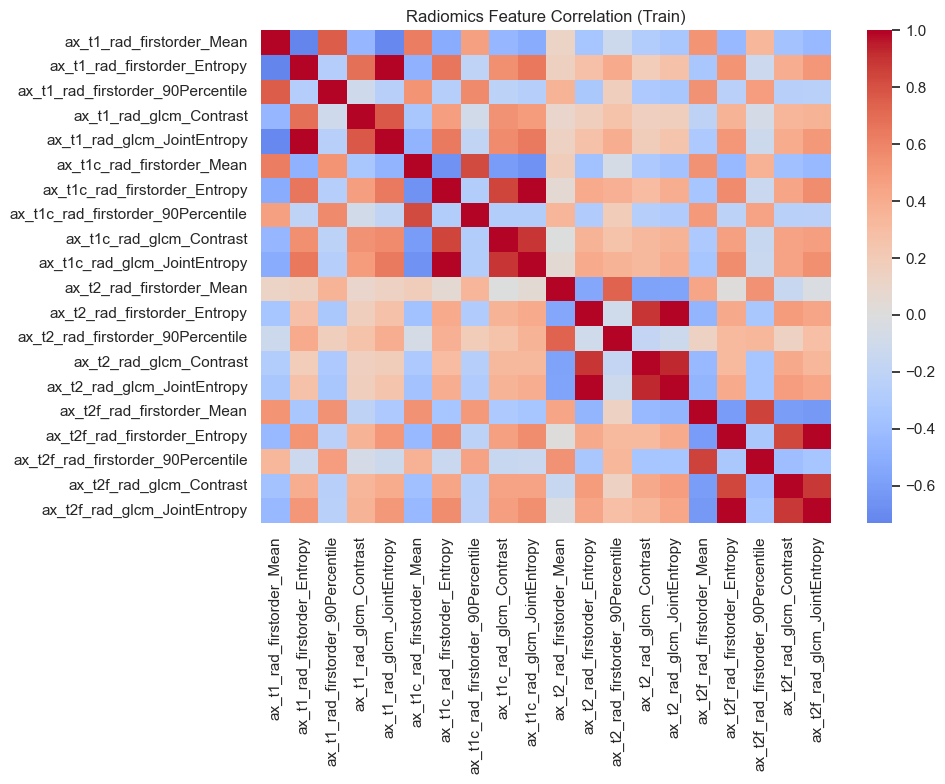

Feature pairs with |r| > 0.95: 4


In [26]:
RADIOMICS_FEAT_COLS = ['rad_firstorder_Mean', 'rad_firstorder_Entropy',
                       'rad_firstorder_90Percentile', 'rad_glcm_Contrast',
                       'rad_glcm_JointEntropy']

rad_frames = []
for mod in MODALITIES:
    df = _clean_cols(pd.read_csv(os.path.join(BASE_DIR, 'radiomics_info', 'train', f'{mod}_radiomics_train.csv')))
    for c in RADIOMICS_FEAT_COLS:
        df = df.rename(columns={c: f'{mod}_{c}'})
    rad_frames.append(df)

rad_all = rad_frames[0][['case_id']].copy()
for df in rad_frames:
    rad_all = rad_all.merge(df.drop(columns=['sex','age','modality'], errors='ignore'), on='case_id', how='left')

rad_numeric = rad_all.select_dtypes(include=[np.number]).drop(columns=['case_id'], errors='ignore')
corr = rad_numeric.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, xticklabels=True, yticklabels=True)
plt.title('Radiomics Feature Correlation (Train)')
plt.tight_layout(); plt.show()

high_corr = (corr.abs() > 0.95).sum().sum() - len(corr)
print(f'Feature pairs with |r| > 0.95: {high_corr // 2}')

---
# 1. Feature Engineering

We load and encode all four modalities, then combine them into a unified feature matrix.

## 1.1 Image Features (2048-d × 4 modalities, zero-pad if missing)

In [27]:
def load_image_features(meta_dict, base_dir=None):
    if base_dir is None:
        base_dir = str(TRAIN_VAL_ROOT)
    case_ids = sorted(meta_dict.keys(), key=int)
    features = []
    for cid in case_ids:
        case_feats = []
        for mod in MODALITIES:
            npy_path = os.path.join(base_dir, 'image_features', 'image_features', cid, mod, 'image.npy')
            if os.path.exists(npy_path):
                case_feats.append(np.load(npy_path))
            else:
                case_feats.append(np.zeros(2048, dtype=np.float32))
        features.append(np.concatenate(case_feats))
    return np.array(features), case_ids

X_img_train, train_ids = load_image_features(train_meta)
X_img_val,   val_ids   = load_image_features(val_meta)
X_img_test,  test_ids  = load_image_features(test_meta, str(TEST_ROOT))
print(f'Image — Train: {X_img_train.shape}, Val: {X_img_val.shape}, Test: {X_img_test.shape}')

Image — Train: (1983, 8192), Val: (283, 8192), Test: (378, 8192)


## 1.2 Radiomics Features (5 × 4 modalities, NaN → 0)

In [28]:
def load_radiomics(split, case_ids, base_dir=None):
    if base_dir is None:
        base_dir = str(TEST_ROOT if split == 'test' else TRAIN_VAL_ROOT)
    all_feats = pd.DataFrame({'case_id': [int(c) for c in case_ids]})
    for mod in MODALITIES:
        df = _clean_cols(pd.read_csv(os.path.join(base_dir, 'radiomics_info', split, f'{mod}_radiomics_{split}.csv')))
        rename = {c: f'{mod}_{c}' for c in RADIOMICS_FEAT_COLS}
        df = df[['case_id'] + RADIOMICS_FEAT_COLS].rename(columns=rename)
        all_feats = all_feats.merge(df, on='case_id', how='left')
    feat_cols = [c for c in all_feats.columns if c != 'case_id']
    all_feats[feat_cols] = all_feats[feat_cols].fillna(0)
    all_feats = all_feats.set_index('case_id').loc[[int(c) for c in case_ids]]
    return all_feats.values

X_rad_train = load_radiomics('train', train_ids)
X_rad_val   = load_radiomics('val',   val_ids)
X_rad_test  = load_radiomics('test',  test_ids)
print(f'Radiomics — Train: {X_rad_train.shape}, Val: {X_rad_val.shape}, Test: {X_rad_test.shape}')

Radiomics — Train: (1983, 20), Val: (283, 20), Test: (378, 20)


## 1.3 Clinical Features (from CSV; demographics sourced from clinical_information)

In [29]:
def _clinical_csv_path(split: str, base_dir: str) -> str:
    root = Path(base_dir)
    flat = root / 'clinical_information' / f'{split}_patient_info.csv'
    nested = root / 'clinical_information' / split / f'{split}_patient_info.csv'
    if nested.is_file():
        return str(nested)
    if flat.is_file():
        return str(flat)
    raise FileNotFoundError(
        f'Could not find clinical CSV for split={split!r} under {base_dir} (tried {nested} and {flat}).'
    )


def load_clinical(split, case_ids, base_dir=None):
    if base_dir is None:
        base_dir = str(TEST_ROOT if split == 'test' else TRAIN_VAL_ROOT)
    df = _clean_cols(pd.read_csv(_clinical_csv_path(split, base_dir)))
    df = df.set_index('case_id').loc[[int(c) for c in case_ids]].reset_index()
    return df

df_clin_train = load_clinical('train', train_ids)
df_clin_val   = load_clinical('val',   val_ids)
df_clin_test  = load_clinical('test',  test_ids)

sex_map = {'female': 0, 'male': 1, 'unknown': 2}
for df in [df_clin_train, df_clin_val, df_clin_test]:
    df['Sex_enc'] = df['Sex'].map(sex_map)

train_age_median = df_clin_train['Age'].median()
for df in [df_clin_train, df_clin_val, df_clin_test]:
    df['Age_filled'] = df['Age'].fillna(train_age_median)

intensity_map = {'hypointense': 0, 'isointense': 1, 'hyperintense': 2,
                 'heterogeneous': 3, 'homogeneous': 4, 'unknown': 5}
intensity_cols = ['Signal Intensity (T1)', 'Signal Intensity (T1c)',
                  'Signal Intensity (T2)', 'Signal Intensity (T2-FLAIR)']
for df in [df_clin_train, df_clin_val, df_clin_test]:
    for col in intensity_cols:
        df[col + '_enc'] = df[col].map(intensity_map).fillna(5).astype(int)

location_keywords = ['frontal', 'temporal', 'parietal', 'occipital', 'cerebellum',
                     'sellar', 'sella', 'pituitary', 'pineal', 'ventricle',
                     'brainstem', 'cerebellopontine', 'thalamus', 'basal',
                     'left', 'right', 'bilateral', 'midline']
for df in [df_clin_train, df_clin_val, df_clin_test]:
    loc_lower = df['Tumor Location'].str.lower().fillna('')
    for kw in location_keywords:
        df[f'loc_{kw}'] = loc_lower.str.contains(kw).astype(int)

clinical_feat_cols = (['Sex_enc', 'Age_filled'] +
                      [c + '_enc' for c in intensity_cols] +
                      [f'loc_{kw}' for kw in location_keywords])

X_clin_train = df_clin_train[clinical_feat_cols].values.astype(float)
X_clin_val   = df_clin_val[clinical_feat_cols].values.astype(float)
X_clin_test  = df_clin_test[clinical_feat_cols].values.astype(float)
print(f'Clinical — Train: {X_clin_train.shape}, Val: {X_clin_val.shape}, Test: {X_clin_test.shape}')

Clinical — Train: (1983, 24), Val: (283, 24), Test: (378, 24)


## 1.4 Text Features (TF-IDF from radiology reports)

In [30]:
def _report_to_text(report):
    if isinstance(report, str):
        return report
    if isinstance(report, dict):
        parts = [str(report.get(k, '')).strip() for k in ['finding', 'impression'] if report.get(k)]
        if not parts:
            parts = [str(v).strip() for v in report.values() if v]
        return ' '.join(parts)
    if isinstance(report, list):
        return ' '.join(_report_to_text(x) for x in report if x).strip()
    return '' if report is None else str(report)


def get_reports(meta_dict, case_ids):
    return [_report_to_text(meta_dict[c].get('report', '')) for c in case_ids]


tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2), stop_words='english', min_df=3)
X_text_train = tfidf.fit_transform(get_reports(train_meta, train_ids)).toarray()
X_text_val   = tfidf.transform(get_reports(val_meta, val_ids)).toarray()
X_text_test  = tfidf.transform(get_reports(test_meta, test_ids)).toarray()
print(f'Text — Train: {X_text_train.shape}, Val: {X_text_val.shape}, Test: {X_text_test.shape}')

Text — Train: (1983, 500), Val: (283, 500), Test: (378, 500)


## 1.5 PCA, Standardize, Encode Labels

In [31]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold

TEXT_VECTORIZER_KWARGS = {
    'max_features': 500,
    'ngram_range': (1, 2),
    'stop_words': 'english',
    'min_df': 3,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

train_reports = get_reports(train_meta, train_ids)
val_reports = get_reports(val_meta, val_ids)
test_reports = get_reports(test_meta, test_ids)


def slice_reports(reports, idx):
    return [reports[i] for i in idx]


def build_text_features(train_reports_subset, eval_reports_subset):
    tfidf_local = TfidfVectorizer(**TEXT_VECTORIZER_KWARGS)
    X_train_text = tfidf_local.fit_transform(train_reports_subset).toarray()
    X_eval_text = tfidf_local.transform(eval_reports_subset).toarray()
    return X_train_text, X_eval_text, tfidf_local


def build_image_pca_features(X_train_img, X_eval_img, n_components=256):
    n_comp = min(n_components, X_train_img.shape[0], X_train_img.shape[1])
    pca_local = PCA(n_components=n_comp, random_state=SEED)
    X_train_img_pca = pca_local.fit_transform(X_train_img)
    X_eval_img_pca = pca_local.transform(X_eval_img)
    return X_train_img_pca, X_eval_img_pca, pca_local


def make_array_fold_builder(X):
    def _builder(train_idx, eval_idx):
        return X[train_idx], X[eval_idx]

    return _builder


def compute_balanced_sample_weights(y):
    classes = np.unique(y)
    weights = compute_class_weight('balanced', classes=classes, y=y)
    weight_map = dict(zip(classes, weights))
    return np.array([weight_map[label] for label in y])


def build_multimodal_numeric_features(
    X_img_train_src,
    X_img_eval_src,
    X_rad_train_src,
    X_rad_eval_src,
    X_clin_train_src,
    X_clin_eval_src,
    text_train_reports_src,
    text_eval_reports_src,
    img_pca_components=256,
    rad_keep_idx=None,
):
    X_img_train_fs, X_img_eval_fs, pca_local = build_image_pca_features(
        X_img_train_src,
        X_img_eval_src,
        n_components=img_pca_components,
    )
    X_text_train_fs, X_text_eval_fs, tfidf_local = build_text_features(
        text_train_reports_src,
        text_eval_reports_src,
    )

    if rad_keep_idx is None:
        rad_keep_idx = np.arange(X_rad_train_src.shape[1])
    else:
        rad_keep_idx = np.asarray(rad_keep_idx, dtype=int)

    X_rad_train_fs = X_rad_train_src[:, rad_keep_idx]
    X_rad_eval_fs = X_rad_eval_src[:, rad_keep_idx]

    train_modalities = {
        'img': X_img_train_fs.astype(np.float32),
        'rad': X_rad_train_fs.astype(np.float32),
        'clin': X_clin_train_src.astype(np.float32),
        'text': X_text_train_fs.astype(np.float32),
    }
    eval_modalities = {
        'img': X_img_eval_fs.astype(np.float32),
        'rad': X_rad_eval_fs.astype(np.float32),
        'clin': X_clin_eval_src.astype(np.float32),
        'text': X_text_eval_fs.astype(np.float32),
    }

    return {
        'train_modalities': train_modalities,
        'eval_modalities': eval_modalities,
        'X_train_all': np.hstack([train_modalities['img'], train_modalities['rad'], train_modalities['clin'], train_modalities['text']]),
        'X_eval_all': np.hstack([eval_modalities['img'], eval_modalities['rad'], eval_modalities['clin'], eval_modalities['text']]),
        'pca': pca_local,
        'tfidf': tfidf_local,
        'img_explained_var': pca_local.explained_variance_ratio_.sum(),
        'rad_keep_idx': rad_keep_idx,
    }


def build_image_only_fold(train_idx, eval_idx, img_pca_components=256):
    X_train_img_pca, X_eval_img_pca, _ = build_image_pca_features(
        X_img_train[train_idx],
        X_img_train[eval_idx],
        n_components=img_pca_components,
    )
    return X_train_img_pca, X_eval_img_pca


def build_text_only_fold(train_idx, eval_idx):
    X_train_text_fold, X_eval_text_fold, _ = build_text_features(
        slice_reports(train_reports, train_idx),
        slice_reports(train_reports, eval_idx),
    )
    return X_train_text_fold, X_eval_text_fold


def build_multimodal_fold(train_idx, eval_idx, img_pca_components=256, rad_keep_idx=None):
    bundle = build_multimodal_numeric_features(
        X_img_train[train_idx],
        X_img_train[eval_idx],
        X_rad_train[train_idx],
        X_rad_train[eval_idx],
        X_clin_train[train_idx],
        X_clin_train[eval_idx],
        slice_reports(train_reports, train_idx),
        slice_reports(train_reports, eval_idx),
        img_pca_components=img_pca_components,
        rad_keep_idx=rad_keep_idx,
    )
    return bundle['train_modalities'], bundle['eval_modalities']


def build_early_fusion_fold(train_idx, eval_idx, img_pca_components=256, rad_keep_idx=None):
    bundle = build_multimodal_numeric_features(
        X_img_train[train_idx],
        X_img_train[eval_idx],
        X_rad_train[train_idx],
        X_rad_train[eval_idx],
        X_clin_train[train_idx],
        X_clin_train[eval_idx],
        slice_reports(train_reports, train_idx),
        slice_reports(train_reports, eval_idx),
        img_pca_components=img_pca_components,
        rad_keep_idx=rad_keep_idx,
    )
    return bundle['X_train_all'], bundle['X_eval_all']


def cross_validate_with_feature_builder(y, feature_builder, estimator, fit_kwargs_builder=None):
    scores = []
    for train_idx, eval_idx in skf.split(np.zeros(len(y)), y):
        X_train_fold, X_eval_fold = feature_builder(train_idx, eval_idx)
        scaler_fold = StandardScaler()
        X_train_fold_scaled = scaler_fold.fit_transform(X_train_fold)
        X_eval_fold_scaled = scaler_fold.transform(X_eval_fold)
        fold_model = clone(estimator)
        fit_kwargs = {} if fit_kwargs_builder is None else fit_kwargs_builder(y[train_idx])
        fold_model.fit(X_train_fold_scaled, y[train_idx], **fit_kwargs)
        y_pred_fold = fold_model.predict(X_eval_fold_scaled)
        scores.append(f1_score(y[eval_idx], y_pred_fold, average='macro'))
    return np.array(scores)


pca_img = PCA(n_components=256, random_state=SEED)
X_img_train_pca = pca_img.fit_transform(X_img_train)
X_img_val_pca   = pca_img.transform(X_img_val)
X_img_test_pca  = pca_img.transform(X_img_test)
print(f'PCA explained variance (256 comp): {pca_img.explained_variance_ratio_.sum():.4f}')

tfidf = TfidfVectorizer(**TEXT_VECTORIZER_KWARGS)
X_text_train = tfidf.fit_transform(train_reports).toarray()
X_text_val   = tfidf.transform(val_reports).toarray()
X_text_test  = tfidf.transform(test_reports).toarray()

# Early-fusion feature matrix
X_train_all = np.hstack([X_img_train_pca, X_rad_train, X_clin_train, X_text_train])
X_val_all   = np.hstack([X_img_val_pca,   X_rad_val,   X_clin_val,   X_text_val])
X_test_all  = np.hstack([X_img_test_pca,  X_rad_test,  X_clin_test,  X_text_test])
print(f'Early-fusion features: {X_train_all.shape[1]}d (img 256 + rad {X_rad_train.shape[1]} + clin {X_clin_train.shape[1]} + text {X_text_train.shape[1]})')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_all)
X_val_scaled   = scaler.transform(X_val_all)
X_test_scaled  = scaler.transform(X_test_all)

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform([train_labels[c] for c in train_ids])
y_val   = label_encoder.transform([val_labels[c] for c in val_ids])
print(f'Labels: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}')

# Class weights for imbalance handling
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))
sample_weights_train = np.array([class_weight_dict[y] for y in y_train])
for idx, w in class_weight_dict.items():
    print(f'  {label_encoder.inverse_transform([idx])[0]}: weight={w:.3f}')

PCA explained variance (256 comp): 0.9218
Early-fusion features: 800d (img 256 + rad 20 + clin 24 + text 500)
Labels: {'Brain Metastase Tumour': 0, 'Glioma': 1, 'Meningioma': 2, 'Pineal tumour and Choroid plexus tumour': 3, 'Tumors of the sellar region': 4}
  Brain Metastase Tumour: weight=1.574
  Glioma: weight=0.429
  Meningioma: weight=0.545
  Pineal tumour and Choroid plexus tumour: weight=17.243
  Tumors of the sellar region: weight=7.082


---
# 2. Stage 1 — Single-Modality Baselines

Before fusion, we evaluate each modality independently to understand its discriminative power. This directly informs which modalities are worth fusing and which fusion strategy to use.

**Methodology (Lecture 4.1 — Cross-Validation)**:

For each modality we follow a two-step evaluation protocol:

1. **Primary**: **Stratified 5-fold CV on the training set** — produces `mean ± std` Macro-F1 across folds. This is the number we use for **model selection**, because it captures generalization variance.
2. **Reference**: **Held-out `val.json` evaluation** — a single-point estimate on data never seen during CV or training. Used to confirm that CV results transfer.

After CV-based selection, we **retrain the chosen model on the full training set** and report the held-out metrics.

**Evaluation metrics** (aligned with Kaggle & proposal):

| Metric | Role | Rationale |
|---|---|---|
| **Macro-F1** | **Primary** | Treats all 5 classes equally; directly penalizes poor minority-class recall — critical given ~40:1 class imbalance. This is the metric we optimize toward. |
| **Weighted-F1** | Secondary | Weights each class by support; reflects overall sample-level performance. |
| **Accuracy** | Reference | Easy to interpret but misleading under class imbalance (a model predicting only Glioma/Meningioma can achieve >80% accuracy). |
| **Per-class Precision / Recall / F1** | Diagnostic | Identifies which specific tumor types are under-served by each modality. |

> **Note on Kaggle scoring**: The competition leaderboard uses **F1 score**. Since our task is multiclass (5 classes), the Kaggle F1 is computed as **macro-averaged F1** across all classes. Our primary metric (Macro-F1) is therefore directly aligned with the competition evaluation.

In [32]:
from sklearn.metrics import accuracy_score


def eval_modality(X_tr, X_va, y_tr, y_va, name, model=None, cv_feature_builder=None, cv_fit_kwargs_builder=None):
    """
    Two-step evaluation per Lecture 4.1:
      1. Stratified 5-fold CV on training set  →  primary (model selection)
      2. Retrain on full training set → eval on held-out val  →  reference
    """
    if model is None:
        model = lgb.LGBMClassifier(n_estimators=300, max_depth=8, learning_rate=0.05,
                                   class_weight='balanced', random_state=SEED, verbose=-1)

    if cv_feature_builder is None:
        cv_feature_builder = make_array_fold_builder(X_tr)
    cv_scores = cross_validate_with_feature_builder(
        y_tr,
        cv_feature_builder,
        model,
        fit_kwargs_builder=cv_fit_kwargs_builder,
    )

    # ── Step 2: Retrain on full training set → held-out val (reference) ──
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_va_s = sc.transform(X_va)
    model.fit(X_tr_s, y_tr)
    y_pred = model.predict(X_va_s)

    acc = accuracy_score(y_va, y_pred)
    f1_macro = f1_score(y_va, y_pred, average='macro')
    f1_weighted = f1_score(y_va, y_pred, average='weighted')

    print(f'\n{"="*60}')
    print(f'  {name}')
    print(f'{"="*60}')
    print(f'  [CV]      Macro-F1 = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}  '
          f'(folds: {", ".join(f"{s:.3f}" for s in cv_scores)})')
    print(f'  [Val]     Macro-F1 = {f1_macro:.4f}  |  Accuracy = {acc:.4f}  |  '
          f'Weighted-F1 = {f1_weighted:.4f}')
    print(f'\nClassification Report (held-out val):')
    print(classification_report(y_va, y_pred,
                                target_names=label_encoder.classes_, digits=4))

    return {'accuracy': acc, 'macro_f1': f1_macro, 'weighted_f1': f1_weighted,
            'cv_scores': cv_scores, 'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
            'y_pred': y_pred, 'model': model, 'scaler': sc}


# ── Run all four modalities ──
print('=' * 60)
print('  Stage 1 — Single-Modality Baselines (LightGBM)')
print('  Evaluation: 5-Fold CV (primary, leakage-free) + Held-out Val (reference)')
print('=' * 60)

single_detail = {}
single_models = {}
single_scalers = {}

stage1_configs = [
    ('Image (PCA-256)', X_img_train_pca, X_img_val_pca, lambda tr, va: build_image_only_fold(tr, va, img_pca_components=256)),
    ('Radiomics (20-d)', X_rad_train, X_rad_val, make_array_fold_builder(X_rad_train)),
    ('Clinical (24-d)', X_clin_train, X_clin_val, make_array_fold_builder(X_clin_train)),
    ('Text (TF-IDF 500)', X_text_train, X_text_val, build_text_only_fold),
]

for mod_name, Xtr, Xva, cv_builder in stage1_configs:
    res = eval_modality(
        Xtr,
        Xva,
        y_train,
        y_val,
        mod_name,
        cv_feature_builder=cv_builder,
    )
    single_detail[mod_name] = res
    single_models[mod_name] = res['model']
    single_scalers[mod_name] = res['scaler']

single_results = {k: v['macro_f1'] for k, v in single_detail.items()}

  Stage 1 — Single-Modality Baselines (LightGBM)
  Evaluation: 5-Fold CV (primary, leakage-free) + Held-out Val (reference)

  Image (PCA-256)
  [CV]      Macro-F1 = 0.2727 ± 0.0084  (folds: 0.274, 0.257, 0.272, 0.281, 0.280)
  [Val]     Macro-F1 = 0.2962  |  Accuracy = 0.6184  |  Weighted-F1 = 0.5793

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.3333    0.0833    0.1333        36
                                 Glioma     0.6135    0.7576    0.6780       132
                             Meningioma     0.6486    0.6923    0.6698       104
Pineal tumour and Choroid plexus tumour     0.0000    0.0000    0.0000         3
            Tumors of the sellar region     0.0000    0.0000    0.0000         8

                               accuracy                         0.6184       283
                              macro avg     0.3191    0.3066    0.2962       283
        

## 2.1 Stage 1 — Summary & Visualization

Below we consolidate the single-modality results into:
1. **Summary comparison table** (Accuracy, Macro-F1, Weighted-F1)
2. **Confusion matrices** (one per modality, 2×2 grid)
3. **Per-class F1 grouped bar chart** across modalities

This follows the reporting style of Tutorial 7 (Result Comparison).

Single-Modality Performance Summary
  CV = Stratified 5-Fold on train.json (primary)
  Val = Held-out val.json (reference)
                   CV Macro-F1 (mean)  CV Macro-F1 (std)  Val Macro-F1  Val Accuracy  Val Weighted-F1
Modality                                                                                             
Image (PCA-256)                0.2727             0.0084        0.2962        0.6184           0.5793
Radiomics (20-d)               0.2802             0.0336        0.2899        0.4947           0.4821
Clinical (24-d)                0.6384             0.0487        0.6688        0.7279           0.7322
Text (TF-IDF 500)              0.6895             0.0525        0.7027        0.8481           0.8497


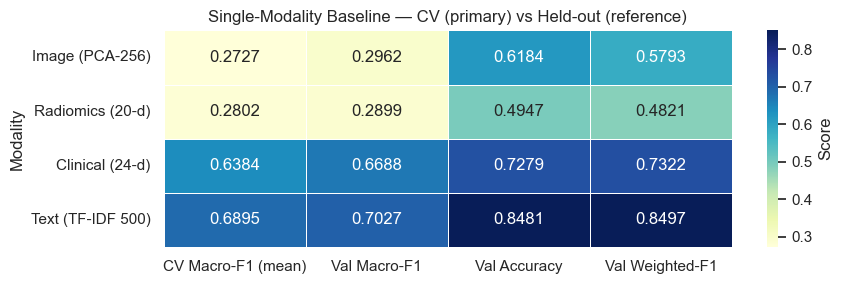

In [33]:
# ── 2.1.1  Summary comparison table (CV + held-out) ──
summary_rows = []
for mod, d in single_detail.items():
    summary_rows.append({
        'Modality': mod,
        'CV Macro-F1 (mean)': d['cv_mean'],
        'CV Macro-F1 (std)': d['cv_std'],
        'Val Macro-F1': d['macro_f1'],
        'Val Accuracy': d['accuracy'],
        'Val Weighted-F1': d['weighted_f1'],
    })
df_summary = pd.DataFrame(summary_rows).set_index('Modality')
print('Single-Modality Performance Summary')
print('  CV = Stratified 5-Fold on train.json (primary)')
print('  Val = Held-out val.json (reference)')
print('=' * 70)
print(df_summary.to_string(float_format='{:.4f}'.format))

fig, ax = plt.subplots(figsize=(9, 3))
df_plot = df_summary[['CV Macro-F1 (mean)', 'Val Macro-F1', 'Val Accuracy', 'Val Weighted-F1']]
sns.heatmap(df_plot, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Score'})
ax.set_title('Single-Modality Baseline — CV (primary) vs Held-out (reference)')
plt.tight_layout()
plt.show()

In [80]:
# AUROC
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

n_classes = len(label_encoder.classes_)
y_val_bin = label_binarize(y_val, classes=range(n_classes))

mod_val_data = {
    'Image (PCA-256)':   X_img_val_pca,
    'Radiomics (20-d)':  X_rad_val,
    'Clinical (24-d)':   X_clin_val,
    'Text (TF-IDF 500)': X_text_val,
}

print("Single-Modality AUROC (macro, one-vs-rest)")
print("=" * 50)
for mod_name, d in single_detail.items():
    X_va = mod_val_data[mod_name]
    X_va_s = d['scaler'].transform(X_va)
    y_proba = d['model'].predict_proba(X_va_s)
    auroc = roc_auc_score(y_val_bin, y_proba, average='macro', multi_class='ovr')
    print(f"  {mod_name:<22s}  AUROC = {auroc:.4f}")

Single-Modality AUROC (macro, one-vs-rest)
  Image (PCA-256)         AUROC = 0.7344
  Radiomics (20-d)        AUROC = 0.6687
  Clinical (24-d)         AUROC = 0.9218
  Text (TF-IDF 500)       AUROC = 0.9588


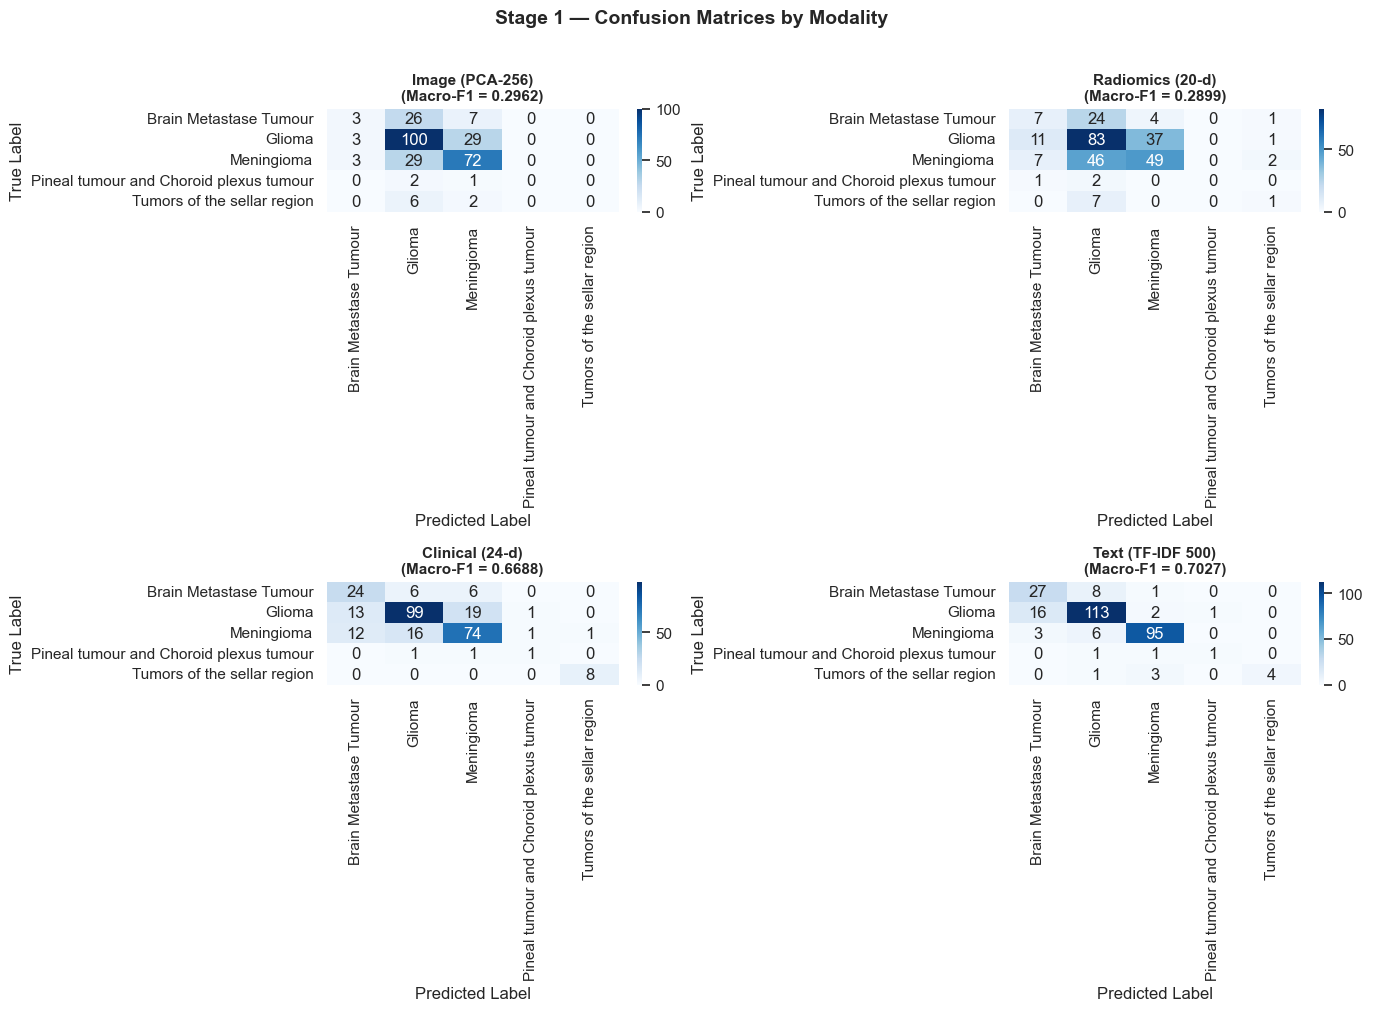

In [34]:
# ── 2.1.2  Confusion matrices (2×2 grid) ──
class_names = label_encoder.classes_
modalities = list(single_detail.keys())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for idx, mod in enumerate(modalities):
    cm = confusion_matrix(y_val, single_detail[mod]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[idx])
    axes[idx].set_title(f'{mod}\n(Macro-F1 = {single_detail[mod]["macro_f1"]:.4f})',
                        fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.suptitle('Stage 1 — Confusion Matrices by Modality', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

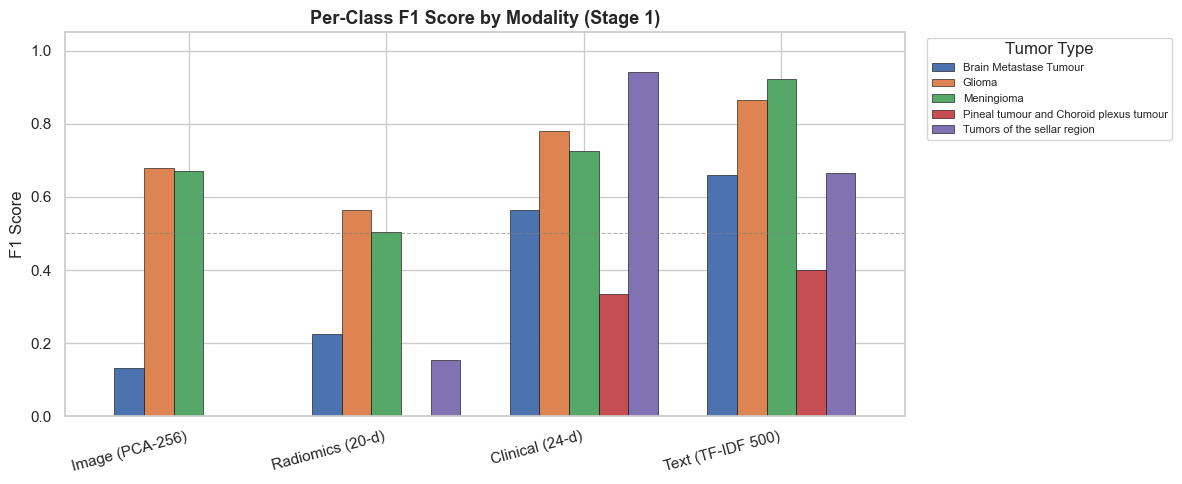


Per-class F1 detail:
                   Brain Metastase Tumour  Glioma  Meningioma  Pineal tumour and Choroid plexus tumour  Tumors of the sellar region
Image (PCA-256)                    0.1333  0.6780      0.6698                                   0.0000                       0.0000
Radiomics (20-d)                   0.2258  0.5646      0.5052                                   0.0000                       0.1538
Clinical (24-d)                    0.5647  0.7795      0.7255                                   0.3333                       0.9412
Text (TF-IDF 500)                  0.6585  0.8659      0.9223                                   0.4000                       0.6667


In [35]:
# ── 2.1.3  Per-class F1 grouped bar chart ──
from sklearn.metrics import f1_score as _f1

per_class_data = {}
for mod, d in single_detail.items():
    per_class_f1 = _f1(y_val, d['y_pred'], average=None, labels=range(len(class_names)))
    per_class_data[mod] = per_class_f1

df_perclass = pd.DataFrame(per_class_data, index=class_names).T

fig, ax = plt.subplots(figsize=(12, 5))
df_perclass.plot(kind='bar', ax=ax, width=0.75, edgecolor='black', linewidth=0.4)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score by Modality (Stage 1)', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax.legend(title='Tumor Type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.set_ylim(0, 1.05)
ax.axhline(y=0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

print('\nPer-class F1 detail:')
print(df_perclass.round(4).to_string())

---
# 3. Stage 2 — Multimodal Fusion

We compare **early fusion** (concatenated features → single model) and **late fusion** (combine single-modality predictions).

In [36]:
def evaluate_model(model, X_val, y_val, name='Model', run_cv=True, cv_feature_builder=None, cv_fit_kwargs_builder=None):
    """
    Two-step evaluation per Lecture 4.1:
      1. Stratified 5-fold CV on training set  →  primary (model selection)
         Feature builders are fit inside each fold to avoid leakage.
      2. Evaluate fitted model on held-out val  →  reference
    """
    cv_scores = None
    if run_cv:
        if cv_feature_builder is None:
            cv_feature_builder = make_array_fold_builder(X_train_all)
        cv_scores = cross_validate_with_feature_builder(
            y_train,
            cv_feature_builder,
            model,
            fit_kwargs_builder=cv_fit_kwargs_builder,
        )

    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    f1m = f1_score(y_val, y_pred, average='macro')
    f1w = f1_score(y_val, y_pred, average='weighted')

    y_proba = None
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_val)

    print(f'\n{"="*60}')
    print(f'  {name}')
    print(f'{"="*60}')
    if cv_scores is not None:
        print(f'  [CV]  Macro-F1 = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}  '
              f'(folds: {", ".join(f"{s:.3f}" for s in cv_scores)})')
    print(f'  [Val] Macro-F1 = {f1m:.4f}  |  Accuracy = {acc:.4f}  |  '
          f'Weighted-F1 = {f1w:.4f}')
    print(f'\nClassification Report (held-out val):')
    print(classification_report(y_val, y_pred,
                                target_names=label_encoder.classes_, digits=4))

    result = {'macro_f1': f1m, 'accuracy': acc, 'weighted_f1': f1w,
              'y_pred': y_pred, 'y_proba': y_proba}
    if cv_scores is not None:
        result['cv_scores'] = cv_scores
        result['cv_mean'] = cv_scores.mean()
        result['cv_std'] = cv_scores.std()
    return result

early_results = {}
early_detail = {}

In [37]:
# 3.1.1 Logistic Regression (L2) — linear baseline
lr = LogisticRegression(max_iter=2000, C=1.0, class_weight='balanced',
                        solver='lbfgs', random_state=SEED)
lr.fit(X_train_scaled, y_train)
early_detail['LR (L2)'] = evaluate_model(
    lr,
    X_val_scaled,
    y_val,
    'Logistic Regression (L2)',
    cv_feature_builder=build_early_fusion_fold,
)
early_results['LR (L2)'] = early_detail['LR (L2)']['macro_f1']


  Logistic Regression (L2)
  [CV]  Macro-F1 = 0.7098 ± 0.0301  (folds: 0.739, 0.704, 0.702, 0.661, 0.744)
  [Val] Macro-F1 = 0.7039  |  Accuracy = 0.7915  |  Weighted-F1 = 0.7981

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.4898    0.6667    0.5647        36
                                 Glioma     0.8430    0.7727    0.8063       132
                             Meningioma     0.8835    0.8750    0.8792       104
Pineal tumour and Choroid plexus tumour     0.4000    0.6667    0.5000         3
            Tumors of the sellar region     1.0000    0.6250    0.7692         8

                               accuracy                         0.7915       283
                              macro avg     0.7233    0.7212    0.7039       283
                           weighted avg     0.8127    0.7915    0.7981       283



In [38]:
# 3.1.2 Random Forest — bagging ensemble
rf = RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_leaf=2,
                            class_weight='balanced', random_state=SEED, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
early_detail['RF'] = evaluate_model(
    rf,
    X_val_scaled,
    y_val,
    'Random Forest',
    cv_feature_builder=build_early_fusion_fold,
)
early_results['RF'] = early_detail['RF']['macro_f1']


  Random Forest
  [CV]  Macro-F1 = 0.5006 ± 0.0488  (folds: 0.486, 0.586, 0.513, 0.480, 0.439)
  [Val] Macro-F1 = 0.4683  |  Accuracy = 0.7173  |  Weighted-F1 = 0.6818

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.6667    0.1111    0.1905        36
                                 Glioma     0.6685    0.9015    0.7677       132
                             Meningioma     0.8085    0.7308    0.7677       104
Pineal tumour and Choroid plexus tumour     0.0000    0.0000    0.0000         3
            Tumors of the sellar region     0.8000    0.5000    0.6154         8

                               accuracy                         0.7173       283
                              macro avg     0.5887    0.4487    0.4683       283
                           weighted avg     0.7164    0.7173    0.6818       283



In [39]:
# 3.1.3 SVM (RBF kernel)
svm = SVC(C=10, kernel='rbf', gamma='scale', class_weight='balanced',
          random_state=SEED, probability=True)
svm.fit(X_train_scaled, y_train)
early_detail['SVM-RBF'] = evaluate_model(
    svm,
    X_val_scaled,
    y_val,
    'SVM (RBF)',
    cv_feature_builder=build_early_fusion_fold,
)
early_results['SVM-RBF'] = early_detail['SVM-RBF']['macro_f1']


  SVM (RBF)
  [CV]  Macro-F1 = 0.6832 ± 0.0335  (folds: 0.727, 0.696, 0.632, 0.659, 0.702)
  [Val] Macro-F1 = 0.7834  |  Accuracy = 0.8587  |  Weighted-F1 = 0.8581

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.6316    0.6667    0.6486        36
                                 Glioma     0.8540    0.8864    0.8699       132
                             Meningioma     0.9412    0.9231    0.9320       104
Pineal tumour and Choroid plexus tumour     1.0000    0.6667    0.8000         3
            Tumors of the sellar region     1.0000    0.5000    0.6667         8

                               accuracy                         0.8587       283
                              macro avg     0.8854    0.7286    0.7834       283
                           weighted avg     0.8634    0.8587    0.8581       283



In [40]:
# 3.1.4 XGBoost — boosting ensemble
xgb_model = xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, objective='multi:softprob', num_class=5,
    eval_metric='mlogloss', random_state=SEED, use_label_encoder=False)
xgb_model.fit(X_train_scaled, y_train, sample_weight=sample_weights_train)
early_detail['XGB'] = evaluate_model(
    xgb_model,
    X_val_scaled,
    y_val,
    'XGBoost',
    cv_feature_builder=build_early_fusion_fold,
    cv_fit_kwargs_builder=lambda y: {'sample_weight': compute_balanced_sample_weights(y)},
)
early_results['XGB'] = early_detail['XGB']['macro_f1']


  XGBoost
  [CV]  Macro-F1 = 0.6523 ± 0.0317  (folds: 0.695, 0.677, 0.612, 0.656, 0.622)
  [Val] Macro-F1 = 0.7367  |  Accuracy = 0.8339  |  Weighted-F1 = 0.8290

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.6207    0.5000    0.5538        36
                                 Glioma     0.8214    0.8712    0.8456       132
                             Meningioma     0.9048    0.9135    0.9091       104
Pineal tumour and Choroid plexus tumour     1.0000    0.3333    0.5000         3
            Tumors of the sellar region     0.8750    0.8750    0.8750         8

                               accuracy                         0.8339       283
                              macro avg     0.8444    0.6986    0.7367       283
                           weighted avg     0.8299    0.8339    0.8290       283



In [41]:
# 3.1.5 LightGBM
lgb_model = lgb.LGBMClassifier(n_estimators=500, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, num_leaves=63,
    class_weight='balanced', random_state=SEED, verbose=-1)
lgb_model.fit(X_train_scaled, y_train)
early_detail['LGB'] = evaluate_model(
    lgb_model,
    X_val_scaled,
    y_val,
    'LightGBM',
    cv_feature_builder=build_early_fusion_fold,
)
early_results['LGB'] = early_detail['LGB']['macro_f1']


  LightGBM
  [CV]  Macro-F1 = 0.6422 ± 0.0442  (folds: 0.717, 0.666, 0.603, 0.602, 0.623)
  [Val] Macro-F1 = 0.6284  |  Accuracy = 0.8233  |  Weighted-F1 = 0.8153

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.5862    0.4722    0.5231        36
                                 Glioma     0.8014    0.8864    0.8417       132
                             Meningioma     0.9200    0.8846    0.9020       104
Pineal tumour and Choroid plexus tumour     0.0000    0.0000    0.0000         3
            Tumors of the sellar region     0.8750    0.8750    0.8750         8

                               accuracy                         0.8233       283
                              macro avg     0.6365    0.6236    0.6284       283
                           weighted avg     0.8112    0.8233    0.8153       283



In [42]:
# 3.1.6 MLP Neural Network
mlp = MLPClassifier(hidden_layer_sizes=(512, 256, 128), activation='relu',
    max_iter=500, early_stopping=True, validation_fraction=0.1,
    batch_size=64, learning_rate='adaptive', learning_rate_init=0.001, random_state=SEED)
mlp.fit(X_train_scaled, y_train)
early_detail['MLP'] = evaluate_model(
    mlp,
    X_val_scaled,
    y_val,
    'MLP',
    cv_feature_builder=build_early_fusion_fold,
)
early_results['MLP'] = early_detail['MLP']['macro_f1']


  MLP
  [CV]  Macro-F1 = 0.7273 ± 0.0314  (folds: 0.752, 0.723, 0.756, 0.669, 0.736)
  [Val] Macro-F1 = 0.7092  |  Accuracy = 0.8445  |  Weighted-F1 = 0.8433

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.6250    0.6944    0.6579        36
                                 Glioma     0.8636    0.8636    0.8636       132
                             Meningioma     0.9048    0.9135    0.9091       104
Pineal tumour and Choroid plexus tumour     1.0000    0.3333    0.5000         3
            Tumors of the sellar region     0.8000    0.5000    0.6154         8

                               accuracy                         0.8445       283
                              macro avg     0.8387    0.6610    0.7092       283
                           weighted avg     0.8480    0.8445    0.8433       283



## 3.1.7 PyTorch Multi-Branch Multimodal MLP

A modality-specific deep neural network that encodes image PCA, radiomics, clinical, and TF-IDF text features in separate branches before fusion.

In [43]:
class MultiModalTensorDataset(Dataset):
    def __init__(self, modalities, labels=None):
        self.modalities = {
            name: torch.tensor(values, dtype=torch.float32)
            for name, values in modalities.items()
        }
        self.labels = None if labels is None else torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        first_key = next(iter(self.modalities))
        return self.modalities[first_key].shape[0]

    def __getitem__(self, idx):
        item = {name: values[idx] for name, values in self.modalities.items()}
        if self.labels is not None:
            return item, self.labels[idx]
        return item


def build_mlp_block(input_dim, hidden_dims, dropout):
    layers = []
    prev_dim = input_dim
    for hidden_dim in hidden_dims:
        layers.extend([
            nn.Linear(prev_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        ])
        prev_dim = hidden_dim
    return nn.Sequential(*layers)


class MultiBranchMultimodalMLP(nn.Module):
    def __init__(self, input_dims, n_classes, dropout=0.25):
        super().__init__()
        self.img_branch = build_mlp_block(input_dims['img'], [128, 64], dropout)
        self.rad_branch = build_mlp_block(input_dims['rad'], [32, 16], dropout)
        self.clin_branch = build_mlp_block(input_dims['clin'], [32, 16], dropout)
        self.text_branch = build_mlp_block(input_dims['text'], [256, 64], dropout)

        fusion_dim = 64 + 16 + 16 + 64
        self.fusion_head = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, batch):
        img_feat = self.img_branch(batch['img'])
        rad_feat = self.rad_branch(batch['rad'])
        clin_feat = self.clin_branch(batch['clin'])
        text_feat = self.text_branch(batch['text'])
        fused = torch.cat([img_feat, rad_feat, clin_feat, text_feat], dim=1)
        return self.fusion_head(fused)


def get_torch_device():
    if torch.backends.mps.is_available():
        return torch.device('mps')
    if torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')


def set_torch_seed(seed=SEED):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def scale_modalities(train_modalities, val_modalities):
    scalers = {}
    train_scaled = {}
    val_scaled = {}
    for name in train_modalities:
        scaler = StandardScaler()
        train_scaled[name] = scaler.fit_transform(train_modalities[name]).astype(np.float32)
        val_scaled[name] = scaler.transform(val_modalities[name]).astype(np.float32)
        scalers[name] = scaler
    return train_scaled, val_scaled, scalers


def make_class_weight_tensor(y, n_classes, device):
    classes = np.arange(n_classes)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)
    return torch.tensor(weights, dtype=torch.float32, device=device)


def predict_multimodal_mlp(model, modalities, batch_size=128, device=None):
    if device is None:
        device = get_torch_device()

    dataset = MultiModalTensorDataset(modalities)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    model.eval()
    probs = []
    preds = []
    with torch.inference_mode():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            logits = model(batch)
            batch_probs = torch.softmax(logits, dim=1)
            probs.append(batch_probs.cpu().numpy())
            preds.append(batch_probs.argmax(dim=1).cpu().numpy())

    y_proba = np.vstack(probs)
    y_pred = np.concatenate(preds)
    return y_pred, y_proba


def compute_multimodal_loss(model, modalities, labels, criterion, batch_size=128, device=None):
    if device is None:
        device = get_torch_device()

    dataset = MultiModalTensorDataset(modalities, labels)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    model.eval()
    total_loss = 0.0
    with torch.inference_mode():
        for batch, y_batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            y_batch = y_batch.to(device)
            logits = model(batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * y_batch.size(0)
    return total_loss / len(dataset)


def fit_multimodal_mlp(
    train_modalities,
    y_train,
    val_modalities,
    y_val,
    epochs=40,
    batch_size=64,
    lr=1e-3,
    weight_decay=1e-4,
    patience=8,
    dropout=0.25,
    device=None,
    verbose=True,
):
    set_torch_seed(SEED)
    if device is None:
        device = get_torch_device()

    train_scaled, val_scaled, scalers = scale_modalities(train_modalities, val_modalities)
    input_dims = {name: values.shape[1] for name, values in train_scaled.items()}
    n_classes = len(label_encoder.classes_)

    train_dataset = MultiModalTensorDataset(train_scaled, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

    model = MultiBranchMultimodalMLP(input_dims, n_classes=n_classes, dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss(weight=make_class_weight_tensor(y_train, n_classes, device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = []
    best_state = None
    best_val_f1 = -np.inf
    best_val_loss = np.inf
    best_epoch = 0
    wait = 0

    val_features = {name: values for name, values in val_scaled.items()}
    y_val_np = np.asarray(y_val)

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for batch, labels in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(batch)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * labels.size(0)

        train_loss = running_loss / len(train_dataset)
        y_val_pred, y_val_proba = predict_multimodal_mlp(model, val_features, batch_size=batch_size, device=device)
        val_loss = compute_multimodal_loss(
            model,
            val_features,
            y_val_np,
            criterion,
            batch_size=batch_size,
            device=device,
        )
        val_macro_f1 = f1_score(y_val_np, y_val_pred, average='macro')
        val_weighted_f1 = f1_score(y_val_np, y_val_pred, average='weighted')

        history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_macro_f1': val_macro_f1,
            'val_weighted_f1': val_weighted_f1,
        })

        improved = (
            val_macro_f1 > best_val_f1 + 1e-6 or
            (abs(val_macro_f1 - best_val_f1) <= 1e-6 and val_loss < best_val_loss)
        )
        if improved:
            best_val_f1 = val_macro_f1
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if verbose and (epoch == 1 or epoch % 5 == 0 or epoch == epochs):
            print(
                f"    Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
                f"val_loss={val_loss:.4f} | val_macro_f1={val_macro_f1:.4f}"
            )

        if wait >= patience:
            if verbose:
                print(f"    Early stopping at epoch {epoch} (best epoch = {best_epoch})")
            break

    model.load_state_dict(best_state)
    y_pred, y_proba = predict_multimodal_mlp(model, val_features, batch_size=batch_size, device=device)

    return {
        'model': model,
        'scalers': scalers,
        'history': history,
        'device': str(device),
        'y_pred': y_pred,
        'y_proba': y_proba,
        'accuracy': accuracy_score(y_val_np, y_pred),
        'macro_f1': f1_score(y_val_np, y_pred, average='macro'),
        'weighted_f1': f1_score(y_val_np, y_pred, average='weighted'),
        'best_epoch': best_epoch,
    }


def cross_validate_multimodal_mlp(
    modalities,
    y,
    epochs=40,
    batch_size=64,
    lr=1e-3,
    weight_decay=1e-4,
    patience=8,
    dropout=0.25,
    device=None,
    fold_builder=None,
):
    scores = []
    split_source = modalities['img'] if isinstance(modalities, dict) else np.zeros(len(y))
    for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(split_source, y), start=1):
        if fold_builder is None:
            fold_train = {name: values[tr_idx] for name, values in modalities.items()}
            fold_val = {name: values[va_idx] for name, values in modalities.items()}
        else:
            fold_train, fold_val = fold_builder(tr_idx, va_idx)
        fold_result = fit_multimodal_mlp(
            fold_train,
            y[tr_idx],
            fold_val,
            y[va_idx],
            epochs=epochs,
            batch_size=batch_size,
            lr=lr,
            weight_decay=weight_decay,
            patience=patience,
            dropout=dropout,
            device=device,
            verbose=False,
        )
        scores.append(fold_result['macro_f1'])
        print(f"    Fold {fold_idx}: Macro-F1 = {fold_result['macro_f1']:.4f}")
    return np.array(scores)


def evaluate_multimodal_mlp(
    train_modalities,
    val_modalities,
    y_train,
    y_val,
    name='PyTorch Multi-Branch MLP',
    run_cv=True,
    epochs=40,
    batch_size=64,
    lr=1e-3,
    weight_decay=1e-4,
    patience=8,
    dropout=0.25,
    device=None,
    cv_fold_builder=None,
):
    if device is None:
        device = get_torch_device()

    cv_scores = None
    if run_cv:
        if cv_fold_builder is None:
            cv_fold_builder = build_multimodal_fold
        print('    Running 5-fold CV for Multi-Branch MLP (leakage-free builders)...')
        cv_scores = cross_validate_multimodal_mlp(
            train_modalities,
            y_train,
            epochs=epochs,
            batch_size=batch_size,
            lr=lr,
            weight_decay=weight_decay,
            patience=patience,
            dropout=dropout,
            device=device,
            fold_builder=cv_fold_builder,
        )

    print(f'    Training final {name} on full training split...')
    result = fit_multimodal_mlp(
        train_modalities,
        y_train,
        val_modalities,
        y_val,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        weight_decay=weight_decay,
        patience=patience,
        dropout=dropout,
        device=device,
        verbose=True,
    )

    print(f'\n{"="*60}')
    print(f'  {name}')
    print(f'{"="*60}')
    if cv_scores is not None:
        print(f'  [CV]  Macro-F1 = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}  '
              f'(folds: {", ".join(f"{s:.3f}" for s in cv_scores)})')
    print(f"  [Val] Macro-F1 = {result['macro_f1']:.4f}  |  Accuracy = {result['accuracy']:.4f}  |  "
          f"Weighted-F1 = {result['weighted_f1']:.4f}")
    print(f"  [Info] Device = {result['device']} | Best epoch = {result['best_epoch']}")
    print(f'\nClassification Report (held-out val):')
    print(classification_report(y_val, result['y_pred'], target_names=label_encoder.classes_, digits=4))

    if cv_scores is not None:
        result['cv_scores'] = cv_scores
        result['cv_mean'] = cv_scores.mean()
        result['cv_std'] = cv_scores.std()
    return result


train_modalities = {
    'img': X_img_train_pca,
    'rad': X_rad_train,
    'clin': X_clin_train,
    'text': X_text_train,
}
val_modalities = {
    'img': X_img_val_pca,
    'rad': X_rad_val,
    'clin': X_clin_val,
    'text': X_text_val,
}

mm_mlp_name = 'PyTorch Multi-Branch MLP'
early_detail[mm_mlp_name] = evaluate_multimodal_mlp(
    train_modalities,
    val_modalities,
    y_train,
    y_val,
    name=mm_mlp_name,
    run_cv=True,
    epochs=35,
    batch_size=64,
    lr=1e-3,
    weight_decay=1e-4,
    patience=7,
    dropout=0.25,
)
early_results[mm_mlp_name] = early_detail[mm_mlp_name]['macro_f1']

    Running 5-fold CV for Multi-Branch MLP (leakage-free builders)...
    Fold 1: Macro-F1 = 0.7599
    Fold 2: Macro-F1 = 0.7144
    Fold 3: Macro-F1 = 0.7972
    Fold 4: Macro-F1 = 0.7223
    Fold 5: Macro-F1 = 0.7585
    Training final PyTorch Multi-Branch MLP on full training split...
    Epoch 01 | train_loss=1.5532 | val_loss=1.4508 | val_macro_f1=0.4289
    Epoch 05 | train_loss=0.3707 | val_loss=0.5982 | val_macro_f1=0.6627
    Epoch 10 | train_loss=0.1399 | val_loss=0.7872 | val_macro_f1=0.6599
    Epoch 15 | train_loss=0.0960 | val_loss=0.8715 | val_macro_f1=0.6786
    Epoch 20 | train_loss=0.0645 | val_loss=0.9971 | val_macro_f1=0.6816
    Early stopping at epoch 20 (best epoch = 13)

  PyTorch Multi-Branch MLP
  [CV]  Macro-F1 = 0.7505 ± 0.0298  (folds: 0.760, 0.714, 0.797, 0.722, 0.759)
  [Val] Macro-F1 = 0.7045  |  Accuracy = 0.8233  |  Weighted-F1 = 0.8352
  [Info] Device = mps | Best epoch = 13

Classification Report (held-out val):
                                     

## 3.2 Late Fusion — Voting & Stacking

Combine predictions from individually strong models. This preserves modality-specific structure.

In [44]:
late_results = {}
late_detail = {}

# 3.2.1 Soft Voting (early-fusion models combined by probability averaging)
# Note: run_cv=False for ensemble wrappers — CV is done on base learners above
voting_clf = VotingClassifier(estimators=[
    ('svm', SVC(C=10, kernel='rbf', gamma='scale', class_weight='balanced', random_state=SEED, probability=True)),
    ('xgb', xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=SEED, use_label_encoder=False, eval_metric='mlogloss')),
    ('lgb', lgb.LGBMClassifier(n_estimators=500, max_depth=8, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, num_leaves=63, class_weight='balanced', random_state=SEED, verbose=-1)),
    ('lr', LogisticRegression(max_iter=2000, C=1.0, class_weight='balanced', random_state=SEED)),
], voting='soft')
voting_clf.fit(X_train_scaled, y_train)
late_detail['Soft Voting'] = evaluate_model(voting_clf, X_val_scaled, y_val,
                                            'Late Fusion: Soft Voting', run_cv=False)
late_results['Soft Voting'] = late_detail['Soft Voting']['macro_f1']


  Late Fusion: Soft Voting
  [Val] Macro-F1 = 0.7851  |  Accuracy = 0.8516  |  Weighted-F1 = 0.8514

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.6000    0.5833    0.5915        36
                                 Glioma     0.8529    0.8788    0.8657       132
                             Meningioma     0.9406    0.9135    0.9268       104
Pineal tumour and Choroid plexus tumour     0.6667    0.6667    0.6667         3
            Tumors of the sellar region     0.8750    0.8750    0.8750         8

                               accuracy                         0.8516       283
                              macro avg     0.7870    0.7834    0.7851       283
                           weighted avg     0.8516    0.8516    0.8514       283



In [45]:
# 3.2.2 Stacking (meta-learner: LR on base model outputs, internal 5-fold CV)
# StackingClassifier already uses cv=5 internally for generating meta-features
stacking_clf = StackingClassifier(estimators=[
    ('svm', SVC(C=10, kernel='rbf', gamma='scale', class_weight='balanced', random_state=SEED, probability=True)),
    ('xgb', xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=SEED, use_label_encoder=False, eval_metric='mlogloss')),
    ('lgb', lgb.LGBMClassifier(n_estimators=500, max_depth=8, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, num_leaves=63, class_weight='balanced', random_state=SEED, verbose=-1)),
    ('rf', RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_leaf=2, class_weight='balanced', random_state=SEED)),
], final_estimator=LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED), cv=5)
stacking_clf.fit(X_train_scaled, y_train)
late_detail['Stacking'] = evaluate_model(stacking_clf, X_val_scaled, y_val,
                                         'Late Fusion: Stacking', run_cv=False)
late_results['Stacking'] = late_detail['Stacking']['macro_f1']


  Late Fusion: Stacking
  [Val] Macro-F1 = 0.7101  |  Accuracy = 0.8198  |  Weighted-F1 = 0.8331

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.5192    0.7500    0.6136        36
                                 Glioma     0.9027    0.7727    0.8327       132
                             Meningioma     0.9400    0.9038    0.9216       104
Pineal tumour and Choroid plexus tumour     0.2000    0.6667    0.3077         3
            Tumors of the sellar region     0.8750    0.8750    0.8750         8

                               accuracy                         0.8198       283
                              macro avg     0.6874    0.7936    0.7101       283
                           weighted avg     0.8594    0.8198    0.8331       283



## 3.3 Stage 2 — Comprehensive Result Comparison (Tutorial 7 Style)

Following Tutorial 7's reporting pattern, we produce:
1. **Summary table** with Accuracy, Macro-F1, Weighted-F1, and macro-averaged AUROC
2. **Confusion matrix grid** for all fusion models
3. **Multiclass ROC curves** (One-vs-Rest, macro-averaged)
4. **Precision–Recall curves** (One-vs-Rest)

FULL MODEL COMPARISON
  Selection metric = leakage-free 5-Fold CV on train.json when available | Val = held-out reference
                          Primary Selection Score      CV Macro-F1  Val Macro-F1  Val Accuracy  Val Weighted-F1  AUROC (macro)
Model                                                                                                                         
Soft Voting                              0.785143                —      0.785143      0.851590         0.851430       0.968532
PyTorch Multi-Branch MLP                 0.750465  0.7505 ± 0.0298      0.704492      0.823322         0.835171       0.926181
MLP                                      0.727270  0.7273 ± 0.0314      0.709201      0.844523         0.843296       0.920452
Stacking                                 0.710110                —      0.710110      0.819788         0.833100       0.956807
LR (L2)                                  0.709751  0.7098 ± 0.0301      0.703898      0.791519         0.798084     

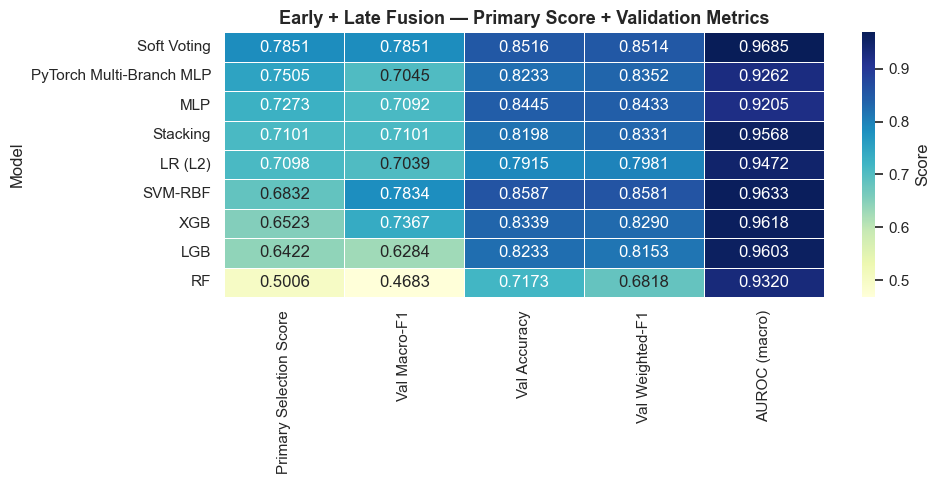

In [46]:
# ── 3.3.1  Comprehensive summary table (CV + Val + AUROC) ──
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

all_detail = {**early_detail, **late_detail}
n_classes = len(label_encoder.classes_)
y_val_bin = label_binarize(y_val, classes=range(n_classes))

summary_rows = []
for name, d in all_detail.items():
    primary_score = d.get('cv_mean', d['macro_f1'])
    row = {'Model': name,
           'Primary Selection Score': primary_score,
           'CV Macro-F1': f"{d.get('cv_mean', float('nan')):.4f} ± {d.get('cv_std', float('nan')):.4f}"
                          if 'cv_mean' in d else '—',
           'Val Macro-F1': d['macro_f1'],
           'Val Accuracy': d['accuracy'],
           'Val Weighted-F1': d['weighted_f1']}
    if d['y_proba'] is not None:
        row['AUROC (macro)'] = roc_auc_score(y_val_bin, d['y_proba'],
                                              average='macro', multi_class='ovr')
    else:
        row['AUROC (macro)'] = float('nan')
    summary_rows.append(row)

df_fusion = pd.DataFrame(summary_rows).set_index('Model')
df_fusion_numeric = df_fusion.drop(columns=['CV Macro-F1']).sort_values('Primary Selection Score', ascending=False)

print('FULL MODEL COMPARISON')
print('  Selection metric = leakage-free 5-Fold CV on train.json when available | Val = held-out reference')
print('=' * 80)
print(df_fusion.sort_values('Primary Selection Score', ascending=False).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df_fusion_numeric, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Score'})
ax.set_title('Early + Late Fusion — Primary Score + Validation Metrics',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

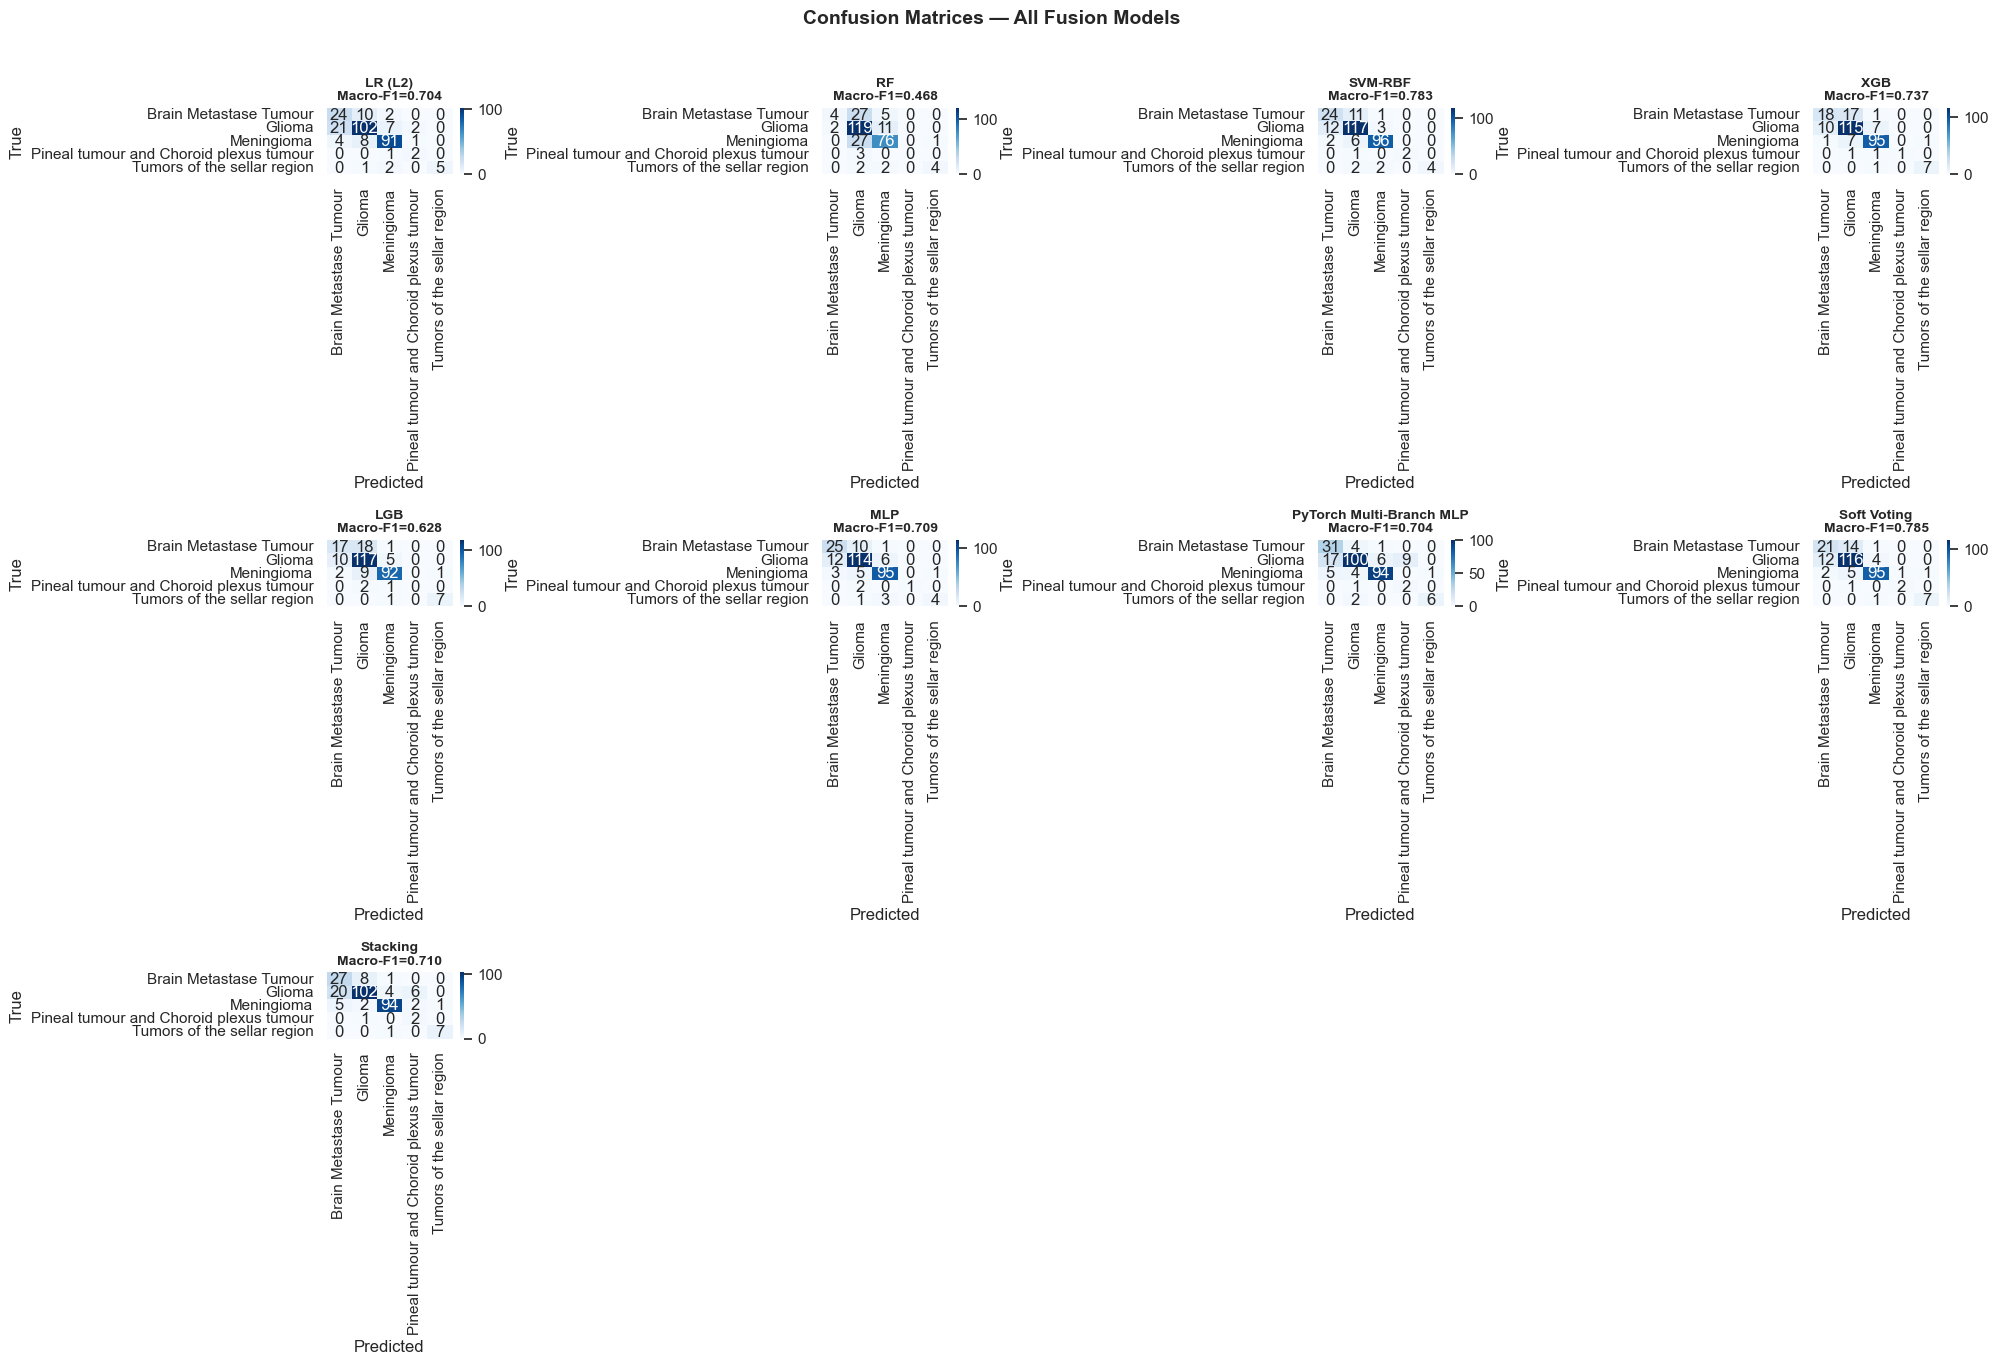

In [47]:
# ── 3.3.2  Confusion matrix grid for all fusion models ──
model_names = list(all_detail.keys())
n_models = len(model_names)
ncols = 4
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes = axes.ravel() if n_models > 1 else [axes]

for idx, name in enumerate(model_names):
    cm = confusion_matrix(y_val, all_detail[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                ax=axes[idx])
    axes[idx].set_title(f'{name}\nMacro-F1={all_detail[name]["macro_f1"]:.3f}',
                        fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('True')
    axes[idx].set_xlabel('Predicted')

for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Confusion Matrices — All Fusion Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

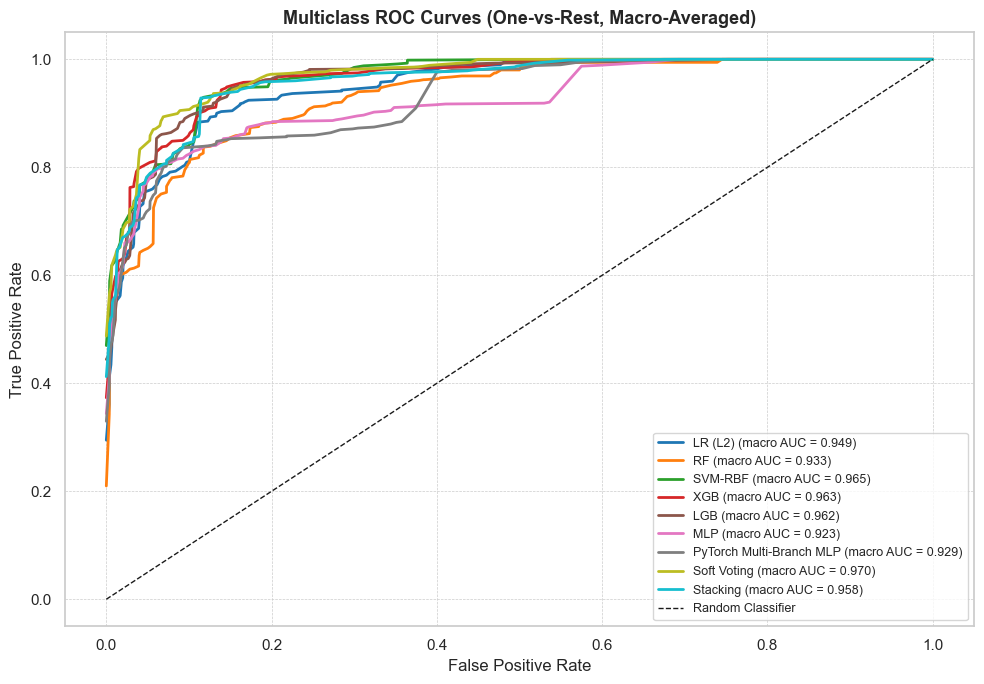

In [48]:
# ── 3.3.3  Multiclass ROC curves (One-vs-Rest, macro-averaged) ──
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(all_detail)))

for (name, d), color in zip(all_detail.items(), colors):
    if d['y_proba'] is None:
        continue
    fpr_macro, tpr_macro = dict(), dict()
    for i in range(n_classes):
        fpr_macro[i], tpr_macro[i], _ = roc_curve(y_val_bin[:, i], d['y_proba'][:, i])
    all_fpr = np.unique(np.concatenate([fpr_macro[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr_macro[i], tpr_macro[i])
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)
    ax.plot(all_fpr, mean_tpr, color=color, lw=2,
            label=f'{name} (macro AUC = {macro_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Multiclass ROC Curves (One-vs-Rest, Macro-Averaged)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(visible=True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

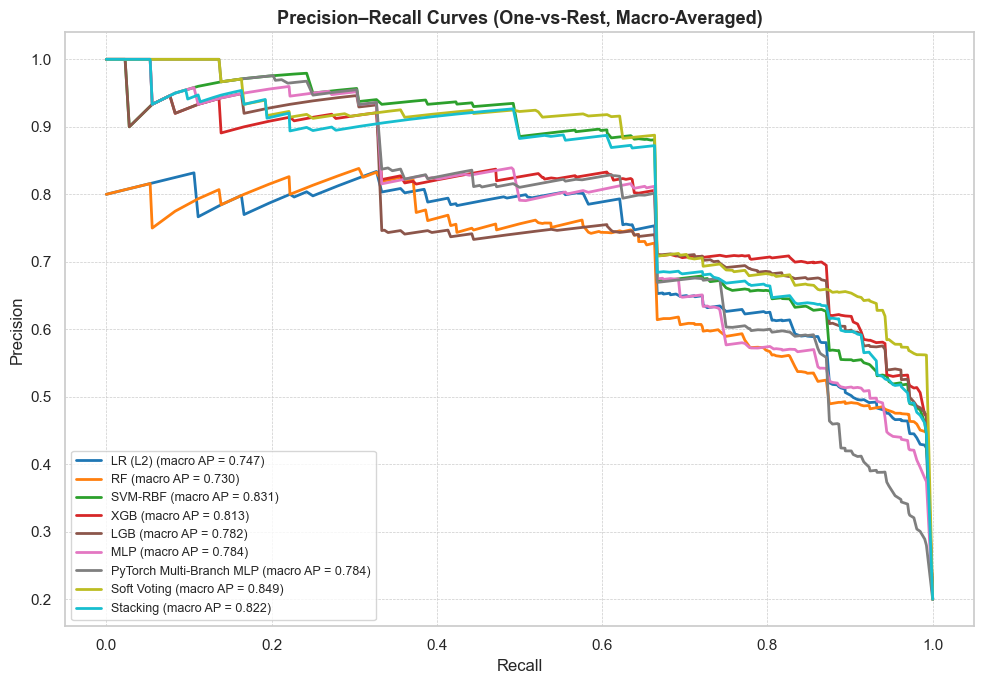

In [49]:
# ── 3.3.4  Precision–Recall curves (One-vs-Rest, macro-averaged) ──
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(10, 7))

for (name, d), color in zip(all_detail.items(), colors):
    if d['y_proba'] is None:
        continue
    prec_avg, rec_avg = dict(), dict()
    for i in range(n_classes):
        prec_avg[i], rec_avg[i], _ = precision_recall_curve(y_val_bin[:, i], d['y_proba'][:, i])
    macro_ap = average_precision_score(y_val_bin, d['y_proba'], average='macro')
    all_recall = np.unique(np.concatenate([rec_avg[i] for i in range(n_classes)]))
    mean_prec = np.zeros_like(all_recall)
    for i in range(n_classes):
        mean_prec += np.interp(all_recall, rec_avg[i][::-1], prec_avg[i][::-1])
    mean_prec /= n_classes
    ax.plot(all_recall, mean_prec, color=color, lw=2,
            label=f'{name} (macro AP = {macro_ap:.3f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision–Recall Curves (One-vs-Rest, Macro-Averaged)', fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
ax.grid(visible=True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

---
# 4. Stage 3 — Optimization

This section implements the planned feature-selection experiments for the multimodal early-fusion pipeline.

### 4.1 Feature Selection
We evaluate three complementary feature-selection strategies on the fused feature space:
- `LASSO (L1)` via sparse multinomial logistic regression coefficients
- `Random Forest` importance ranking
- `Mutual Information` ranking

We also test two structural feature-reduction steps:
- remove radiomics pairs with `|r| > 0.95`
- tune image PCA dimensionality over `128 / 256 / 512`

All comparisons report both `Stratified 5-fold CV Macro-F1` and held-out validation `Macro-F1`.

In [50]:
# ── 4.1.1  Helper utilities for feature-selection experiments ──
rad_feat_names = [f'{mod}_{feat}' for mod in MODALITIES for feat in RADIOMICS_FEAT_COLS]
clin_feat_names = [f'clin_{c}' for c in clinical_feat_cols]
text_feat_names = [f'tfidf_{i}' for i in range(X_text_train.shape[1])]


def get_decorrelated_rad_keep_idx(X_rad_subset, threshold=0.95):
    rad_train_df = pd.DataFrame(X_rad_subset, columns=rad_feat_names)
    rad_corr_abs = rad_train_df.corr().abs()
    upper = rad_corr_abs.where(np.triu(np.ones(rad_corr_abs.shape), k=1).astype(bool))
    high_corr_pairs = (
        upper.stack()
        .sort_values(ascending=False)
        .loc[lambda s: s > threshold]
    )
    rad_drop_cols = [c for c in upper.columns if (upper[c] > threshold).any()]
    rad_keep_cols_local = [c for c in rad_feat_names if c not in rad_drop_cols]
    rad_keep_idx_local = np.array([rad_feat_names.index(c) for c in rad_keep_cols_local], dtype=int)
    return rad_keep_idx_local, rad_keep_cols_local, rad_drop_cols, high_corr_pairs



def build_feature_selection_dataset(img_pca_components=256, rad_keep_cols=None):
    rad_keep_idx = None
    if rad_keep_cols is not None:
        rad_keep_idx = [rad_feat_names.index(c) for c in rad_keep_cols]

    bundle = build_multimodal_numeric_features(
        X_img_train,
        X_img_val,
        X_rad_train,
        X_rad_val,
        X_clin_train,
        X_clin_val,
        train_reports,
        val_reports,
        img_pca_components=img_pca_components,
        rad_keep_idx=rad_keep_idx,
    )

    if rad_keep_cols is None:
        rad_keep_cols = rad_feat_names
    img_feat_names = [f'img_pc{i}' for i in range(bundle['train_modalities']['img'].shape[1])]
    feat_names = img_feat_names + list(rad_keep_cols) + clin_feat_names + text_feat_names
    return bundle['X_train_all'], bundle['X_eval_all'], feat_names, bundle['img_explained_var']



def evaluate_feature_subset(X_train_sel, X_val_sel, y_train, y_val, name, run_cv=True, cv_feature_builder=None):
    model = lgb.LGBMClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        class_weight='balanced',
        random_state=SEED,
        verbose=-1
    )

    scaler_fs = StandardScaler()
    X_train_sel_scaled = scaler_fs.fit_transform(X_train_sel)
    X_val_sel_scaled = scaler_fs.transform(X_val_sel)
    model.fit(X_train_sel_scaled, y_train)
    y_pred = model.predict(X_val_sel_scaled)

    result = {
        'name': name,
        'n_features': X_train_sel.shape[1],
        'val_macro_f1': f1_score(y_val, y_pred, average='macro')
    }

    if run_cv:
        if cv_feature_builder is None:
            cv_feature_builder = make_array_fold_builder(X_train_sel)
        cv_scores = cross_validate_with_feature_builder(y_train, cv_feature_builder, model)
        result['cv_scores'] = cv_scores
        result['cv_mean'] = cv_scores.mean()
        result['cv_std'] = cv_scores.std()

    return result



def rank_features_l1(X_train_fs, y_train):
    scaler_l1 = StandardScaler()
    X_train_scaled_l1 = scaler_l1.fit_transform(X_train_fs)
    l1_selector = LogisticRegression(
        penalty='l1',
        solver='saga',
        C=0.2,
        max_iter=4000,
        class_weight='balanced',
        random_state=SEED
    )
    l1_selector.fit(X_train_scaled_l1, y_train)
    scores = np.abs(l1_selector.coef_).mean(axis=0)
    ranking = np.argsort(scores)[::-1]
    nonzero_idx = np.flatnonzero(scores > 1e-8)
    return scores, ranking, nonzero_idx



def rank_features_rf(X_train_fs, y_train):
    rf_selector = RandomForestClassifier(
        n_estimators=400,
        max_depth=12,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        random_state=SEED,
        n_jobs=-1
    )
    rf_selector.fit(X_train_fs, y_train)
    scores = rf_selector.feature_importances_
    ranking = np.argsort(scores)[::-1]
    return scores, ranking



def rank_features_mi(X_train_fs, y_train):
    scores = mutual_info_classif(X_train_fs, y_train, random_state=SEED)
    ranking = np.argsort(scores)[::-1]
    return scores, ranking



def select_feature_indices(X_train_fs, y_train_fs, method, top_k=None):
    if method == 'L1':
        _, ranking, nonzero_idx = rank_features_l1(X_train_fs, y_train_fs)
        selected_idx = nonzero_idx if top_k == 'nonzero' else ranking[:min(int(top_k), len(ranking))]
    elif method == 'RF':
        _, ranking = rank_features_rf(X_train_fs, y_train_fs)
        selected_idx = ranking[:min(int(top_k), len(ranking))]
    elif method == 'MI':
        _, ranking = rank_features_mi(X_train_fs, y_train_fs)
        selected_idx = ranking[:min(int(top_k), len(ranking))]
    else:
        raise ValueError(f'Unknown feature selection method: {method}')

    if len(selected_idx) == 0:
        selected_idx = np.arange(X_train_fs.shape[1])
    return np.asarray(selected_idx, dtype=int)



def build_feature_selection_fold(
    train_idx,
    eval_idx,
    img_pca_components=256,
    decorrelate_radiomics=True,
    selection_method=None,
    top_k=None,
):
    rad_keep_idx = None
    if decorrelate_radiomics:
        rad_keep_idx, _, _, _ = get_decorrelated_rad_keep_idx(X_rad_train[train_idx])

    bundle = build_multimodal_numeric_features(
        X_img_train[train_idx],
        X_img_train[eval_idx],
        X_rad_train[train_idx],
        X_rad_train[eval_idx],
        X_clin_train[train_idx],
        X_clin_train[eval_idx],
        slice_reports(train_reports, train_idx),
        slice_reports(train_reports, eval_idx),
        img_pca_components=img_pca_components,
        rad_keep_idx=rad_keep_idx,
    )
    X_train_fs = bundle['X_train_all']
    X_eval_fs = bundle['X_eval_all']

    if selection_method is not None:
        selected_idx = select_feature_indices(
            X_train_fs,
            y_train[train_idx],
            selection_method,
            top_k=top_k,
        )
        X_train_fs = X_train_fs[:, selected_idx]
        X_eval_fs = X_eval_fs[:, selected_idx]

    return X_train_fs, X_eval_fs

In [51]:
# ── 4.1.2  Remove highly correlated radiomics features and compare L1 / RF / MI ──
rad_keep_idx, rad_keep_cols, rad_drop_cols, high_corr_pairs = get_decorrelated_rad_keep_idx(X_rad_train)

print('Highly correlated radiomics pairs (|r| > 0.95):')
if len(high_corr_pairs) == 0:
    print('  None found.')
else:
    for (f1, f2), corr_val in high_corr_pairs.items():
        print(f'  {f1:<35s} vs {f2:<35s} | r = {corr_val:.3f}')

print(f'\nRadiomics features before filter: {len(rad_feat_names)}')
print(f'Radiomics features after filter:  {len(rad_keep_cols)}')
if rad_drop_cols:
    print('Dropped features:')
    for c in rad_drop_cols:
        print(f'  - {c}')

X_train_fs, X_val_fs, fs_feat_names, fs_explained_var = build_feature_selection_dataset(
    img_pca_components=256,
    rad_keep_cols=rad_keep_cols
)
print(f'\nFeature-selection dataset: {X_train_fs.shape[1]} features total')
print(f'Image PCA explained variance (256 comp): {fs_explained_var:.4f}')

l1_scores, l1_ranking, l1_nonzero_idx = rank_features_l1(X_train_fs, y_train)
rf_scores, rf_ranking = rank_features_rf(X_train_fs, y_train)
mi_scores, mi_ranking = rank_features_mi(X_train_fs, y_train)

ranking_tables = {
    'L1': pd.Series(l1_scores, index=fs_feat_names).sort_values(ascending=False),
    'RF': pd.Series(rf_scores, index=fs_feat_names).sort_values(ascending=False),
    'MI': pd.Series(mi_scores, index=fs_feat_names).sort_values(ascending=False),
}

print(f'\nL1 non-zero features selected: {len(l1_nonzero_idx)}')
for method, table in ranking_tables.items():
    print(f'\nTop 10 features by {method}:')
    display(table.head(10).to_frame(name='score'))

feature_search_specs = [
    {
        'name': 'All features (de-correlated rad)',
        'selection_method': None,
        'top_k': None,
        'selected_idx': None,
    }
]

k_grid = [64, 128, 256]
for k in k_grid:
    for method, ranking in [('L1', l1_ranking), ('RF', rf_ranking), ('MI', mi_ranking)]:
        selected_idx = ranking[:min(k, len(ranking))]
        feature_search_specs.append({
            'name': f'{method} top-{len(selected_idx)}',
            'selection_method': method,
            'top_k': len(selected_idx),
            'selected_idx': np.asarray(selected_idx, dtype=int),
        })

if len(l1_nonzero_idx) > 0:
    feature_search_specs.append({
        'name': f'L1 non-zero ({len(l1_nonzero_idx)})',
        'selection_method': 'L1',
        'top_k': 'nonzero',
        'selected_idx': np.asarray(l1_nonzero_idx, dtype=int),
    })

fs_results = []
for spec in feature_search_specs:
    if spec['selected_idx'] is None:
        X_train_sel = X_train_fs
        X_val_sel = X_val_fs
    else:
        X_train_sel = X_train_fs[:, spec['selected_idx']]
        X_val_sel = X_val_fs[:, spec['selected_idx']]

    fs_results.append(
        evaluate_feature_subset(
            X_train_sel,
            X_val_sel,
            y_train,
            y_val,
            spec['name'],
            cv_feature_builder=lambda tr, va, spec=spec: build_feature_selection_fold(
                tr,
                va,
                img_pca_components=256,
                decorrelate_radiomics=True,
                selection_method=spec['selection_method'],
                top_k=spec['top_k'],
            ),
        )
    )

fs_summary = pd.DataFrame(fs_results).sort_values(
    ['cv_mean', 'val_macro_f1'],
    ascending=False
).reset_index(drop=True)

print('\nFEATURE SELECTION SUMMARY (sorted by CV Macro-F1, val as reference)')
display(fs_summary.style.format({
    'cv_mean': '{:.4f}',
    'cv_std': '{:.4f}',
    'val_macro_f1': '{:.4f}'
}))

best_fs_config = fs_summary.iloc[0].to_dict()
print(f"\nBest feature-selection config by CV: {best_fs_config['name']} | "
      f"{int(best_fs_config['n_features'])} features | "
      f"CV Macro-F1 = {best_fs_config['cv_mean']:.4f} | "
      f"Val Macro-F1 = {best_fs_config['val_macro_f1']:.4f}")

Highly correlated radiomics pairs (|r| > 0.95):
  ax_t1c_rad_firstorder_Entropy       vs ax_t1c_rad_glcm_JointEntropy        | r = 0.997
  ax_t2_rad_firstorder_Entropy        vs ax_t2_rad_glcm_JointEntropy         | r = 0.997
  ax_t2f_rad_firstorder_Entropy       vs ax_t2f_rad_glcm_JointEntropy        | r = 0.997
  ax_t1_rad_firstorder_Entropy        vs ax_t1_rad_glcm_JointEntropy         | r = 0.991

Radiomics features before filter: 20
Radiomics features after filter:  16
Dropped features:
  - ax_t1_rad_glcm_JointEntropy
  - ax_t1c_rad_glcm_JointEntropy
  - ax_t2_rad_glcm_JointEntropy
  - ax_t2f_rad_glcm_JointEntropy

Feature-selection dataset: 796 features total
Image PCA explained variance (256 comp): 0.9218

L1 non-zero features selected: 493

Top 10 features by L1:


,score
clin_loc_sella,0.365276
img_pc1,0.199732
tfidf_167,0.173841
clin_loc_ventricle,0.139259
tfidf_245,0.134409
tfidf_191,0.134130
clin_Age_filled,0.131277
img_pc115,0.125034
tfidf_351,0.118942
clin_Sex_enc,0.117145



Top 10 features by RF:


,score
clin_loc_sella,0.035097
clin_loc_sellar,0.021985
tfidf_363,0.021066
tfidf_260,0.018257
clin_loc_ventricle,0.012739
tfidf_396,0.012158
tfidf_216,0.011369
tfidf_399,0.010671
tfidf_245,0.010438
tfidf_133,0.010415



Top 10 features by MI:


,score
tfidf_456,0.252014
tfidf_461,0.251431
tfidf_301,0.250678
tfidf_402,0.250577
tfidf_82,0.238429
tfidf_107,0.236042
tfidf_216,0.235963
tfidf_4,0.234314
tfidf_83,0.231632
tfidf_442,0.226165



FEATURE SELECTION SUMMARY (sorted by CV Macro-F1, val as reference)


,name,n_features,val_macro_f1,cv_scores,cv_mean,cv_std
0,MI top-128,128,0.7278,[0.77786691 0.70047629 0.72340744 0.67760771 0.64556371],0.7050,0.0446
1,MI top-256,256,0.7511,[0.65890522 0.69746615 0.6377371 0.6074699 0.62036277],0.6444,0.0317
2,L1 top-128,128,0.6209,[0.72523856 0.6828446 0.60716784 0.60304207 0.58779625],0.6412,0.0534
3,L1 top-256,256,0.6126,[0.65498073 0.68514587 0.61264747 0.5736031 0.63980975],0.6332,0.0379
4,L1 non-zero (493),493,0.6161,[0.68347821 0.64882511 0.59303238 0.59403418 0.62451404],0.6288,0.0343
5,All features (de-correlated rad),796,0.6058,[0.63879512 0.6721915 0.60943819 0.59536624 0.62215449],0.6276,0.0265
6,MI top-64,64,0.6442,[0.68384448 0.64132953 0.62610363 0.55854943 0.58482416],0.6189,0.0438
7,L1 top-64,64,0.5530,[0.66999013 0.66944982 0.63295373 0.53733173 0.55284579],0.6125,0.0569
8,RF top-256,256,0.5649,[0.62992846 0.62900193 0.58403871 0.50146082 0.54808712],0.5785,0.0492
9,RF top-64,64,0.5609,[0.61911257 0.55326179 0.63116297 0.53802239 0.53197013],0.5747,0.0419



Best feature-selection config by CV: MI top-128 | 128 features | CV Macro-F1 = 0.7050 | Val Macro-F1 = 0.7278


PCA TUNING SUMMARY (sorted by CV Macro-F1, val as reference)


,name,n_features,val_macro_f1,cv_scores,cv_mean,cv_std,pca_components,img_explained_var
0,PCA-128 + all non-image features,668,0.7432,[0.69222055 0.69200414 0.67671773 0.61181522 0.66029392],0.6666,0.0298,128,0.8586
1,PCA-256 + all non-image features,796,0.6058,[0.63879512 0.6721915 0.60943819 0.59536624 0.62215449],0.6276,0.0265,256,0.9218
2,PCA-512 + all non-image features,1052,0.7650,[0.68776252 0.64241788 0.58559051 0.59110443 0.55962322],0.6133,0.0459,512,0.9660


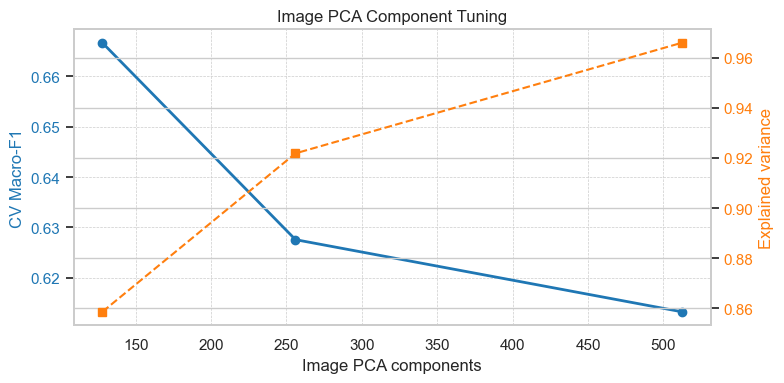

Best PCA setting by CV: 128 components | CV Macro-F1 = 0.6666 | Val Macro-F1 = 0.7432 | Explained variance = 0.8586


In [52]:
# ── 4.1.3  Tune image PCA dimensionality (128 / 256 / 512) ──
pca_tuning_results = []
pca_feature_sets = {}

for n_comp in [128, 256, 512]:
    X_train_pca_fs, X_val_pca_fs, pca_feat_names, explained_var = build_feature_selection_dataset(
        img_pca_components=n_comp,
        rad_keep_cols=rad_keep_cols
    )
    pca_feature_sets[n_comp] = (X_train_pca_fs, X_val_pca_fs, pca_feat_names)

    result = evaluate_feature_subset(
        X_train_pca_fs,
        X_val_pca_fs,
        y_train,
        y_val,
        f'PCA-{n_comp} + all non-image features',
        cv_feature_builder=lambda tr, va, n_comp=n_comp: build_feature_selection_fold(
            tr,
            va,
            img_pca_components=n_comp,
            decorrelate_radiomics=True,
        ),
    )
    result['pca_components'] = n_comp
    result['img_explained_var'] = explained_var
    pca_tuning_results.append(result)

pca_tuning_summary = pd.DataFrame(pca_tuning_results).sort_values(
    ['cv_mean', 'val_macro_f1'],
    ascending=False
).reset_index(drop=True)

print('PCA TUNING SUMMARY (sorted by CV Macro-F1, val as reference)')
display(pca_tuning_summary.style.format({
    'cv_mean': '{:.4f}',
    'cv_std': '{:.4f}',
    'val_macro_f1': '{:.4f}',
    'img_explained_var': '{:.4f}'
}))

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(
    pca_tuning_summary['pca_components'],
    pca_tuning_summary['cv_mean'],
    marker='o',
    linewidth=2,
    color='tab:blue',
    label='CV Macro-F1'
)
ax1.set_xlabel('Image PCA components')
ax1.set_ylabel('CV Macro-F1', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(visible=True, linestyle='--', linewidth=0.5)

ax2 = ax1.twinx()
ax2.plot(
    pca_tuning_summary['pca_components'],
    pca_tuning_summary['img_explained_var'],
    marker='s',
    linestyle='--',
    color='tab:orange',
    label='Explained variance'
)
ax2.set_ylabel('Explained variance', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

ax1.set_title('Image PCA Component Tuning')
plt.tight_layout()
plt.show()

best_pca_config = pca_tuning_summary.iloc[0].to_dict()
print(f"Best PCA setting by CV: {int(best_pca_config['pca_components'])} components | "
      f"CV Macro-F1 = {best_pca_config['cv_mean']:.4f} | "
      f"Val Macro-F1 = {best_pca_config['val_macro_f1']:.4f} | "
      f"Explained variance = {best_pca_config['img_explained_var']:.4f}")

## 4.1.4 Optimization Schemes to SVM-RBF

Since `SVM-RBF` was the strongest early-fusion baseline in Section 3, we re-run the same feature-space optimization ideas under the same SVM hyperparameters:
- de-correlated radiomics
- `L1 / RF / MI` feature ranking
- image PCA dimensionality (`128 / 256 / 512`)

This lets us test whether the improvements observed with `LightGBM` also help the best-performing baseline model.

In [74]:
# ── 4.1.4  Re-run the same optimization schemes with SVM-RBF ──
def build_feature_selection_dataset_with_test(img_pca_components=256, rad_keep_cols=None):
    rad_keep_idx = None
    if rad_keep_cols is not None:
        rad_keep_idx = [rad_feat_names.index(c) for c in rad_keep_cols]

    val_bundle = build_multimodal_numeric_features(
        X_img_train,
        X_img_val,
        X_rad_train,
        X_rad_val,
        X_clin_train,
        X_clin_val,
        train_reports,
        val_reports,
        img_pca_components=img_pca_components,
        rad_keep_idx=rad_keep_idx,
    )
    test_bundle = build_multimodal_numeric_features(
        X_img_train,
        X_img_test,
        X_rad_train,
        X_rad_test,
        X_clin_train,
        X_clin_test,
        train_reports,
        test_reports,
        img_pca_components=img_pca_components,
        rad_keep_idx=rad_keep_idx,
    )

    if rad_keep_cols is None:
        rad_keep_cols = rad_feat_names
    img_feat_names = [f'img_pc{i}' for i in range(val_bundle['train_modalities']['img'].shape[1])]
    feat_names = img_feat_names + list(rad_keep_cols) + clin_feat_names + text_feat_names
    return val_bundle['X_train_all'], val_bundle['X_eval_all'], test_bundle['X_eval_all'], feat_names, val_bundle['img_explained_var']



def evaluate_feature_subset_svm(
    X_train_sel,
    X_val_sel,
    y_train,
    y_val,
    name,
    base_model=None,
    run_cv=True,
    cv_feature_builder=None,
):
    if base_model is None:
        base_model = clone(svm)

    model = clone(base_model)
    scaler_fs = StandardScaler()
    X_train_sel_scaled = scaler_fs.fit_transform(X_train_sel)
    X_val_sel_scaled = scaler_fs.transform(X_val_sel)
    model.fit(X_train_sel_scaled, y_train)
    y_pred = model.predict(X_val_sel_scaled)
    y_proba = model.predict_proba(X_val_sel_scaled) if hasattr(model, 'predict_proba') else None

    result = {
        'name': name,
        'n_features': X_train_sel.shape[1],
        'accuracy': accuracy_score(y_val, y_pred),
        'val_macro_f1': f1_score(y_val, y_pred, average='macro'),
        'val_weighted_f1': f1_score(y_val, y_pred, average='weighted'),
        'y_pred': y_pred,
        'y_proba': y_proba,
        'model': model,
        'scaler': scaler_fs,
    }

    if run_cv:
        if cv_feature_builder is None:
            cv_feature_builder = make_array_fold_builder(X_train_sel)
        cv_scores = cross_validate_with_feature_builder(y_train, cv_feature_builder, base_model)
        result['cv_scores'] = cv_scores
        result['cv_mean'] = cv_scores.mean()
        result['cv_std'] = cv_scores.std()

    return result


svm_opt_feature_sets = {
    'Baseline early fusion (800-d)': {
        'train': X_train_all,
        'val': X_val_all,
        'test': X_test_all,
        'n_features': X_train_all.shape[1],
        'cv_feature_builder': build_early_fusion_fold,
    }
}

X_train_fs_svm, X_val_fs_svm, X_test_fs_svm, fs_feat_names_svm, fs_explained_var_svm = build_feature_selection_dataset_with_test(
    img_pca_components=256,
    rad_keep_cols=rad_keep_cols,
)
for spec in feature_search_specs:
    if spec['selected_idx'] is None:
        train_matrix = X_train_fs_svm
        val_matrix = X_val_fs_svm
        test_matrix = X_test_fs_svm
    else:
        train_matrix = X_train_fs_svm[:, spec['selected_idx']]
        val_matrix = X_val_fs_svm[:, spec['selected_idx']]
        test_matrix = X_test_fs_svm[:, spec['selected_idx']]

    svm_opt_feature_sets[spec['name']] = {
        'train': train_matrix,
        'val': val_matrix,
        'test': test_matrix,
        'n_features': train_matrix.shape[1],
        'cv_feature_builder': lambda tr, va, spec=spec: build_feature_selection_fold(
            tr,
            va,
            img_pca_components=256,
            decorrelate_radiomics=True,
            selection_method=spec['selection_method'],
            top_k=spec['top_k'],
        ),
    }

for n_comp in [128, 256, 512]:
    X_train_pca_svm, X_val_pca_svm, X_test_pca_svm, _, explained_var = build_feature_selection_dataset_with_test(
        img_pca_components=n_comp,
        rad_keep_cols=rad_keep_cols,
    )
    svm_opt_feature_sets[f'PCA-{n_comp} + all non-image features'] = {
        'train': X_train_pca_svm,
        'val': X_val_pca_svm,
        'test': X_test_pca_svm,
        'n_features': X_train_pca_svm.shape[1],
        'img_explained_var': explained_var,
        'cv_feature_builder': lambda tr, va, n_comp=n_comp: build_feature_selection_fold(
            tr,
            va,
            img_pca_components=n_comp,
            decorrelate_radiomics=True,
        ),
    }

svm_opt_results = {}
for name, split_data in svm_opt_feature_sets.items():
    svm_opt_results[name] = evaluate_feature_subset_svm(
        split_data['train'],
        split_data['val'],
        y_train,
        y_val,
        name,
        base_model=svm,
        run_cv=True,
        cv_feature_builder=split_data.get('cv_feature_builder'),
    )

svm_baseline_val = early_detail['SVM-RBF']['macro_f1']
svm_baseline_cv = early_detail['SVM-RBF']['cv_mean']

svm_opt_summary = pd.DataFrame([
    {
        'name': name,
        'n_features': res['n_features'],
        'val_macro_f1': res['val_macro_f1'],
        'val_accuracy': res['accuracy'],
        'val_weighted_f1': res['val_weighted_f1'],
        'cv_mean': res.get('cv_mean', np.nan),
        'cv_std': res.get('cv_std', np.nan),
        'delta_val_vs_baseline': res['val_macro_f1'] - svm_baseline_val,
        'delta_cv_vs_baseline': res.get('cv_mean', np.nan) - svm_baseline_cv,
        'img_explained_var': svm_opt_feature_sets[name].get('img_explained_var', np.nan),
    }
    for name, res in svm_opt_results.items()
]).sort_values(['cv_mean', 'val_macro_f1'], ascending=False).reset_index(drop=True)

print('SVM-RBF OPTIMIZATION SUMMARY (sorted by CV Macro-F1, val as reference)')
print(f'Baseline SVM-RBF from Section 3.1.3 -> CV Macro-F1 = {svm_baseline_cv:.4f}, Val Macro-F1 = {svm_baseline_val:.4f}')
display(svm_opt_summary.style.format({
    'val_macro_f1': '{:.4f}',
    'val_accuracy': '{:.4f}',
    'val_weighted_f1': '{:.4f}',
    'cv_mean': '{:.4f}',
    'cv_std': '{:.4f}',
    'delta_val_vs_baseline': '{:+.4f}',
    'delta_cv_vs_baseline': '{:+.4f}',
    'img_explained_var': '{:.4f}',
}))

best_svm_opt_name = svm_opt_summary.iloc[0]['name']
best_svm_opt_result = svm_opt_results[best_svm_opt_name]
print(f"\nBest SVM-RBF feature config by CV: {best_svm_opt_name} | "
      f"{int(best_svm_opt_result['n_features'])} features | "
      f"CV Macro-F1 = {best_svm_opt_result['cv_mean']:.4f} | "
      f"Val Macro-F1 = {best_svm_opt_result['val_macro_f1']:.4f}")

svm_rbf_optimized_model_name = None
optimized_test_matrices = globals().get('optimized_test_matrices', {})

if best_svm_opt_name != 'Baseline early fusion (800-d)' and best_svm_opt_result['cv_mean'] > svm_baseline_cv:
    svm_rbf_optimized_model_name = f'SVM-RBF (Optimized 4.1: {best_svm_opt_name})'
    early_detail[svm_rbf_optimized_model_name] = {
        'macro_f1': best_svm_opt_result['val_macro_f1'],
        'accuracy': best_svm_opt_result['accuracy'],
        'weighted_f1': best_svm_opt_result['val_weighted_f1'],
        'y_pred': best_svm_opt_result['y_pred'],
        'y_proba': best_svm_opt_result['y_proba'],
        'cv_scores': best_svm_opt_result['cv_scores'],
        'cv_mean': best_svm_opt_result['cv_mean'],
        'cv_std': best_svm_opt_result['cv_std'],
        'model': best_svm_opt_result['model'],
        'scaler': best_svm_opt_result['scaler'],
        'feature_config': best_svm_opt_name,
    }
    early_results[svm_rbf_optimized_model_name] = best_svm_opt_result['val_macro_f1']
    if 'all_detail' in globals():
        all_detail[svm_rbf_optimized_model_name] = early_detail[svm_rbf_optimized_model_name]
    optimized_test_matrices[svm_rbf_optimized_model_name] = best_svm_opt_result['scaler'].transform(
        svm_opt_feature_sets[best_svm_opt_name]['test']
    )
    print(f'Added {svm_rbf_optimized_model_name} to downstream model comparison.')
else:
    print('No optimized SVM-RBF feature configuration outperformed the original 800-d baseline on CV Macro-F1.')


SVM-RBF OPTIMIZATION SUMMARY (sorted by CV Macro-F1, val as reference)
Baseline SVM-RBF from Section 3.1.3 -> CV Macro-F1 = 0.6832, Val Macro-F1 = 0.7834


,name,n_features,val_macro_f1,val_accuracy,val_weighted_f1,cv_mean,cv_std,delta_val_vs_baseline,delta_cv_vs_baseline,img_explained_var
0,MI top-256,256,0.6935,0.8410,0.8352,0.7521,0.0139,-0.0900,+0.0689,nan
1,PCA-128 + all non-image features,668,0.7636,0.8410,0.8385,0.7292,0.0383,-0.0198,+0.0460,0.8586
2,L1 top-128,128,0.7632,0.8269,0.8266,0.7081,0.0216,-0.0202,+0.0249,nan
3,L1 top-256,256,0.7545,0.8198,0.8183,0.7011,0.0364,-0.0289,+0.0179,nan
4,MI top-128,128,0.6883,0.8375,0.8363,0.6934,0.0456,-0.0951,+0.0102,nan
5,All features (de-correlated rad),796,0.7834,0.8587,0.8581,0.6846,0.0347,+0.0000,+0.0014,nan
6,PCA-256 + all non-image features,796,0.7834,0.8587,0.8581,0.6846,0.0347,+0.0000,+0.0014,0.9218
7,Baseline early fusion (800-d),800,0.7834,0.8587,0.8581,0.6832,0.0335,+0.0000,+0.0000,nan
8,L1 non-zero (493),493,0.7418,0.8375,0.8358,0.6794,0.0346,-0.0417,-0.0039,nan
9,L1 top-64,64,0.5420,0.7385,0.7373,0.6673,0.0449,-0.2415,-0.0159,nan



Best SVM-RBF feature config by CV: MI top-256 | 256 features | CV Macro-F1 = 0.7521 | Val Macro-F1 = 0.6935
Added SVM-RBF (Optimized 4.1: MI top-256) to downstream model comparison.


## 4.1.5 Optimization Schemes to XGBoost

We also transfer the same 4.1 feature-space optimization schemes to `XGBoost`, since it was another strong early-fusion model in Section 3.

This comparison tests whether the best feature subsets for `LightGBM` or `SVM-RBF` also improve boosting-based multiclass classification under the same `XGBoost` hyperparameters.

In [54]:
# ── 4.1.5  Re-run the same optimization schemes with XGBoost ──
def evaluate_feature_subset_xgb(
    X_train_sel,
    X_val_sel,
    y_train,
    y_val,
    name,
    base_model=None,
    run_cv=True,
    cv_feature_builder=None,
):
    if base_model is None:
        base_model = clone(xgb_model)

    model = clone(base_model)
    scaler_fs = StandardScaler()
    X_train_sel_scaled = scaler_fs.fit_transform(X_train_sel)
    X_val_sel_scaled = scaler_fs.transform(X_val_sel)
    model.fit(X_train_sel_scaled, y_train, sample_weight=compute_balanced_sample_weights(y_train))
    y_pred = model.predict(X_val_sel_scaled)
    y_proba = model.predict_proba(X_val_sel_scaled) if hasattr(model, 'predict_proba') else None

    result = {
        'name': name,
        'n_features': X_train_sel.shape[1],
        'accuracy': accuracy_score(y_val, y_pred),
        'val_macro_f1': f1_score(y_val, y_pred, average='macro'),
        'val_weighted_f1': f1_score(y_val, y_pred, average='weighted'),
        'y_pred': y_pred,
        'y_proba': y_proba,
        'model': model,
        'scaler': scaler_fs,
    }

    if run_cv:
        if cv_feature_builder is None:
            cv_feature_builder = make_array_fold_builder(X_train_sel)
        cv_scores = cross_validate_with_feature_builder(
            y_train,
            cv_feature_builder,
            base_model,
            fit_kwargs_builder=lambda y: {'sample_weight': compute_balanced_sample_weights(y)},
        )
        result['cv_scores'] = cv_scores
        result['cv_mean'] = cv_scores.mean()
        result['cv_std'] = cv_scores.std()

    return result


xgb_opt_feature_sets = {
    'Baseline early fusion (800-d)': {
        'train': X_train_all,
        'val': X_val_all,
        'test': X_test_all,
        'n_features': X_train_all.shape[1],
        'cv_feature_builder': build_early_fusion_fold,
    },
}

for spec in feature_search_specs:
    if spec['selected_idx'] is None:
        train_matrix = X_train_fs_svm
        val_matrix = X_val_fs_svm
        test_matrix = X_test_fs_svm
    else:
        train_matrix = X_train_fs_svm[:, spec['selected_idx']]
        val_matrix = X_val_fs_svm[:, spec['selected_idx']]
        test_matrix = X_test_fs_svm[:, spec['selected_idx']]

    xgb_opt_feature_sets[spec['name']] = {
        'train': train_matrix,
        'val': val_matrix,
        'test': test_matrix,
        'n_features': train_matrix.shape[1],
        'cv_feature_builder': lambda tr, va, spec=spec: build_feature_selection_fold(
            tr,
            va,
            img_pca_components=256,
            decorrelate_radiomics=True,
            selection_method=spec['selection_method'],
            top_k=spec['top_k'],
        ),
    }

for n_comp in [128, 256, 512]:
    X_train_pca_xgb, X_val_pca_xgb, X_test_pca_xgb, _, explained_var = build_feature_selection_dataset_with_test(
        img_pca_components=n_comp,
        rad_keep_cols=rad_keep_cols,
    )
    xgb_opt_feature_sets[f'PCA-{n_comp} + all non-image features'] = {
        'train': X_train_pca_xgb,
        'val': X_val_pca_xgb,
        'test': X_test_pca_xgb,
        'n_features': X_train_pca_xgb.shape[1],
        'img_explained_var': explained_var,
        'cv_feature_builder': lambda tr, va, n_comp=n_comp: build_feature_selection_fold(
            tr,
            va,
            img_pca_components=n_comp,
            decorrelate_radiomics=True,
        ),
    }

xgb_opt_results = {}
for name, split_data in xgb_opt_feature_sets.items():
    xgb_opt_results[name] = evaluate_feature_subset_xgb(
        split_data['train'],
        split_data['val'],
        y_train,
        y_val,
        name,
        base_model=xgb_model,
        run_cv=True,
        cv_feature_builder=split_data.get('cv_feature_builder'),
    )

xgb_baseline_val = early_detail['XGB']['macro_f1']
xgb_baseline_cv = early_detail['XGB']['cv_mean']

xgb_opt_summary = pd.DataFrame([
    {
        'name': name,
        'n_features': res['n_features'],
        'val_macro_f1': res['val_macro_f1'],
        'val_accuracy': res['accuracy'],
        'val_weighted_f1': res['val_weighted_f1'],
        'cv_mean': res.get('cv_mean', np.nan),
        'cv_std': res.get('cv_std', np.nan),
        'delta_val_vs_baseline': res['val_macro_f1'] - xgb_baseline_val,
        'delta_cv_vs_baseline': res.get('cv_mean', np.nan) - xgb_baseline_cv,
        'img_explained_var': xgb_opt_feature_sets[name].get('img_explained_var', np.nan),
    }
    for name, res in xgb_opt_results.items()
]).sort_values(['cv_mean', 'val_macro_f1'], ascending=False).reset_index(drop=True)

print('XGBOOST OPTIMIZATION SUMMARY (sorted by CV Macro-F1, val as reference)')
print(f'Baseline XGB from Section 3.1.4 -> CV Macro-F1 = {xgb_baseline_cv:.4f}, Val Macro-F1 = {xgb_baseline_val:.4f}')
display(xgb_opt_summary.style.format({
    'val_macro_f1': '{:.4f}',
    'val_accuracy': '{:.4f}',
    'val_weighted_f1': '{:.4f}',
    'cv_mean': '{:.4f}',
    'cv_std': '{:.4f}',
    'delta_val_vs_baseline': '{:+.4f}',
    'delta_cv_vs_baseline': '{:+.4f}',
    'img_explained_var': '{:.4f}',
}))

best_xgb_opt_name = xgb_opt_summary.iloc[0]['name']
best_xgb_opt_result = xgb_opt_results[best_xgb_opt_name]
print(f"\nBest XGBoost feature config by CV: {best_xgb_opt_name} | "
      f"{int(best_xgb_opt_result['n_features'])} features | "
      f"CV Macro-F1 = {best_xgb_opt_result['cv_mean']:.4f} | "
      f"Val Macro-F1 = {best_xgb_opt_result['val_macro_f1']:.4f}")

xgb_optimized_model_name = None
optimized_test_matrices = globals().get('optimized_test_matrices', {})

if best_xgb_opt_name != 'Baseline early fusion (800-d)' and best_xgb_opt_result['cv_mean'] > xgb_baseline_cv:
    xgb_optimized_model_name = f'XGB (Optimized 4.1: {best_xgb_opt_name})'
    early_detail[xgb_optimized_model_name] = {
        'macro_f1': best_xgb_opt_result['val_macro_f1'],
        'accuracy': best_xgb_opt_result['accuracy'],
        'weighted_f1': best_xgb_opt_result['val_weighted_f1'],
        'y_pred': best_xgb_opt_result['y_pred'],
        'y_proba': best_xgb_opt_result['y_proba'],
        'cv_scores': best_xgb_opt_result['cv_scores'],
        'cv_mean': best_xgb_opt_result['cv_mean'],
        'cv_std': best_xgb_opt_result['cv_std'],
        'model': best_xgb_opt_result['model'],
        'scaler': best_xgb_opt_result['scaler'],
        'feature_config': best_xgb_opt_name,
    }
    early_results[xgb_optimized_model_name] = best_xgb_opt_result['val_macro_f1']
    if 'all_detail' in globals():
        all_detail[xgb_optimized_model_name] = early_detail[xgb_optimized_model_name]
    optimized_test_matrices[xgb_optimized_model_name] = best_xgb_opt_result['scaler'].transform(
        xgb_opt_feature_sets[best_xgb_opt_name]['test']
    )
    print(f'Added {xgb_optimized_model_name} to downstream model comparison.')
else:
    print('No optimized XGBoost feature configuration outperformed the original 800-d baseline on CV Macro-F1.')


XGBOOST OPTIMIZATION SUMMARY (sorted by CV Macro-F1, val as reference)
Baseline XGB from Section 3.1.4 -> CV Macro-F1 = 0.6523, Val Macro-F1 = 0.7367


,name,n_features,val_macro_f1,val_accuracy,val_weighted_f1,cv_mean,cv_std,delta_val_vs_baseline,delta_cv_vs_baseline,img_explained_var
0,MI top-128,128,0.7060,0.8339,0.8322,0.7029,0.0440,-0.0308,+0.0507,nan
1,PCA-128 + all non-image features,668,0.7155,0.8233,0.8216,0.6876,0.0248,-0.0212,+0.0354,0.8586
2,L1 non-zero (493),493,0.7712,0.8375,0.8333,0.6639,0.0375,+0.0345,+0.0117,nan
3,MI top-256,256,0.7535,0.8587,0.8554,0.6634,0.0494,+0.0168,+0.0111,nan
4,L1 top-128,128,0.6257,0.8127,0.8092,0.6623,0.0425,-0.1110,+0.0100,nan
5,All features (de-correlated rad),796,0.7366,0.8269,0.8227,0.6595,0.0363,-0.0001,+0.0073,nan
6,PCA-256 + all non-image features,796,0.7366,0.8269,0.8227,0.6595,0.0363,-0.0001,+0.0073,0.9218
7,Baseline early fusion (800-d),800,0.7367,0.8339,0.8290,0.6523,0.0317,+0.0000,+0.0000,nan
8,L1 top-64,64,0.5691,0.7633,0.7545,0.6497,0.0326,-0.1676,-0.0026,nan
9,L1 top-256,256,0.6279,0.7986,0.7951,0.6452,0.0486,-0.1088,-0.0070,nan



Best XGBoost feature config by CV: MI top-128 | 128 features | CV Macro-F1 = 0.7029 | Val Macro-F1 = 0.7060
Added XGB (Optimized 4.1: MI top-128) to downstream model comparison.


### 4.2 Class Imbalance Mitigation
- Compare 3 training strategies on fixed validation split: `class_weight='balanced'`, random over-sampling, and SMOTE
- Evaluate with macro-F1 and per-class F1 (to focus on minority classes)



In [55]:
# —— Section 4.2  Imbalance Mitigation  ——

from collections import Counter
import pandas as pd
from sklearn.base import clone
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold, ParameterGrid, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from imblearn.over_sampling import RandomOverSampler, SMOTE


def evaluate_on_validation(model, X_train_fit, y_train_fit, X_val_eval, y_val_eval):
    model.fit(X_train_fit, y_train_fit)
    y_pred = model.predict(X_val_eval)
    macro = f1_score(y_val_eval, y_pred, average='macro')
    per_cls = f1_score(y_val_eval, y_pred, average=None, labels=range(len(class_names)))
    return macro, per_cls, y_pred


print('\n' + '=' * 78)
print('Section 4.2 - Class Imbalance Mitigation (SVM-RBF / fixed validation split)')
print('=' * 78)

imbalance_strategies = {
    'class_weight=balanced': lambda X, y: (X, y),
    'random_oversampling': lambda X, y: RandomOverSampler(random_state=SEED).fit_resample(X, y),
    'smote': lambda X, y: SMOTE(random_state=SEED, k_neighbors=1).fit_resample(X, y),
}

imbalance_rows = []
base_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(C=10, kernel='rbf', gamma='scale', class_weight='balanced', probability=True, random_state=SEED))
])

for strat_name, sampler in imbalance_strategies.items():
    X_tr_res, y_tr_res = sampler(X_train_all, y_train)
    macro_f1, per_class_f1, y_pred = evaluate_on_validation(clone(base_svm), X_tr_res, y_tr_res, X_val_all, y_val)

    row = {
        'strategy': strat_name,
        'train_distribution': str(dict(Counter(y_tr_res))),
        'val_macro_f1': round(macro_f1, 4),
    }
    for i, cls_name in enumerate(class_names):
        row[f'F1_{cls_name}'] = round(float(per_class_f1[i]), 4)
    imbalance_rows.append(row)

imbalance_df = pd.DataFrame(imbalance_rows).sort_values('val_macro_f1', ascending=False)
print(imbalance_df.to_string(index=False))

best_imbalance_row = imbalance_df.iloc[0]
best_imbalance_strategy = best_imbalance_row['strategy']
print(f"\nBest imbalance strategy by validation Macro-F1: {best_imbalance_strategy} ({best_imbalance_row['val_macro_f1']:.4f})")




Section 4.2 - Class Imbalance Mitigation (SVM-RBF / fixed validation split)
             strategy                       train_distribution  val_macro_f1  F1_Brain Metastase Tumour  F1_Glioma  F1_Meningioma  F1_Pineal tumour and Choroid plexus tumour  F1_Tumors of the sellar region
class_weight=balanced   {0: 252, 2: 728, 1: 924, 4: 56, 3: 23}        0.7834                     0.6486     0.8699         0.9320                                         0.8                          0.6667
  random_oversampling {0: 924, 2: 924, 1: 924, 4: 924, 3: 924}        0.7173                     0.6389     0.8614         0.9194                                         0.5                          0.6667
                smote {0: 924, 2: 924, 1: 924, 4: 924, 3: 924}        0.6921                     0.6286     0.8676         0.9187                                         0.5                          0.5455

Best imbalance strategy by validation Macro-F1: class_weight=balanced (0.7834)


### 4.3 Hyperparameter Tuning
- Run stratified 5-fold CV (macro-F1) for top-2 models from Section 5.1 (`SVM-RBF`, `LGB`)
- Refit best params on full train split and report validation macro-F1



In [56]:
# —— Section 4.3  Hyperparameter Tuning ——

print('\n' + '=' * 78)
print('Section 4.3 - Hyperparameter Tuning (5-fold CV Macro-F1, leakage-free)')
print('=' * 78)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


def early_fusion_cv_scores(estimator):
    return cross_validate_with_feature_builder(
        y_train,
        build_early_fusion_fold,
        estimator,
    )


model_search_space = {
    'SVM-RBF': {
        'factory': lambda p: SVC(class_weight='balanced', probability=True, random_state=SEED, **p),
        'param_grid': {
            'C': [3, 10, 30],
            'gamma': ['scale', 0.1, 0.03],
            'kernel': ['rbf'],
        },
    },
    'LGB': {
        'factory': lambda p: lgb.LGBMClassifier(
            random_state=SEED,
            class_weight='balanced',
            verbose=-1,
            n_jobs=-1,
            **p,
        ),
        'param_grid': {
            'n_estimators': [300, 500, 700],
            'max_depth': [6, 8, -1],
            'learning_rate': [0.03, 0.05, 0.08],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0],
        },
    },
}

cv_summary_rows = []
tuned_model_objects = globals().get('tuned_model_objects', {})
tuned_test_matrices = globals().get('tuned_test_matrices', {})

for model_name, spec in model_search_space.items():
    print(f"\nTuning {model_name} ...")
    best_cv = -1.0
    best_params = None
    best_cv_scores = None

    for params in ParameterGrid(spec['param_grid']):
        estimator = spec['factory'](params)
        cv_scores = early_fusion_cv_scores(estimator)
        cv_mean = float(cv_scores.mean())
        if cv_mean > best_cv:
            best_cv = cv_mean
            best_params = params
            best_cv_scores = cv_scores

    best_model = spec['factory'](best_params)
    if model_name == 'SVM-RBF':
        best_model = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', best_model),
        ])
    else:
        best_model = Pipeline([
            ('scaler', StandardScaler()),
            ('model', best_model),
        ])

    best_model.fit(X_train_all, y_train)
    y_val_pred = best_model.predict(X_val_all)
    val_macro = f1_score(y_val, y_val_pred, average='macro')

    optimized_name = f"{model_name} (Tuned 4.3)"
    early_results[optimized_name] = float(val_macro)
    all_detail[optimized_name] = {
        'macro_f1': float(val_macro),
        'weighted_f1': float(f1_score(y_val, y_val_pred, average='weighted')),
        'accuracy': float((y_val_pred == y_val).mean()),
        'cv_mean': float(best_cv),
        'cv_std': float(np.std(best_cv_scores)) if best_cv_scores is not None else float('nan'),
        'y_pred': y_val_pred,
        'model': best_model,
    }

    tuned_model_objects[optimized_name] = best_model
    tuned_test_matrices[optimized_name] = X_test_all

    cv_summary_rows.append({
        'model': model_name,
        'best_params': str(best_params),
        'cv_macro_f1': round(best_cv, 4),
        'val_macro_f1': round(float(val_macro), 4),
        'saved_as': optimized_name,
    })

globals()['tuned_model_objects'] = tuned_model_objects
globals()['tuned_test_matrices'] = tuned_test_matrices

cv_summary_df = pd.DataFrame(cv_summary_rows).sort_values(['cv_macro_f1', 'val_macro_f1'], ascending=False)
print('\nBest configurations from Section 4.3:')
print(cv_summary_df.to_string(index=False))





Section 4.3 - Hyperparameter Tuning (5-fold CV Macro-F1, leakage-free)

Tuning SVM-RBF ...

Tuning LGB ...

Best configurations from Section 4.3:
  model                                                                                              best_params  cv_macro_f1  val_macro_f1            saved_as
SVM-RBF                                                              {'C': 3, 'gamma': 'scale', 'kernel': 'rbf'}       0.6902        0.7609 SVM-RBF (Tuned 4.3)
    LGB {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': -1, 'n_estimators': 700, 'subsample': 0.8}       0.6584        0.6280     LGB (Tuned 4.3)


In [77]:
# Force submission model: SVM-RBF (Optimized 4.1: L1 top-128)
forced_model_name = 'SVM-RBF (Optimized 4.1: L1 top-128)'
forced_config_name = 'L1 top-128'

if 'svm_opt_results' not in globals() or 'svm_opt_feature_sets' not in globals():
    raise KeyError('svm_opt_results/svm_opt_feature_sets not found. Please rerun Section 4.1.4 first.')

# svm_opt_results keys are feature config names (e.g., "L1 top-128"), not full model names.
if forced_config_name not in svm_opt_results:
    available = ', '.join(sorted(map(str, svm_opt_results.keys())))
    raise KeyError(
        f"{forced_config_name} not found in svm_opt_results. Available configs: {available}"
    )

forced_res = svm_opt_results[forced_config_name]
strict_cv_selected_name = forced_model_name
strict_cv_selected_model = forced_res['model']
strict_cv_selected_test_matrix = forced_res['scaler'].transform(
    svm_opt_feature_sets[forced_config_name]['test']
)

print(f'Forced submission model -> {strict_cv_selected_name} (config: {forced_config_name})')

Forced submission model -> SVM-RBF (Optimized 4.1: L1 top-128) (config: L1 top-128)


---
# 5. Model Analysis

Targeting the workload/analysis component (40% of grade).

## 5.1 Model Comparison Summary (Early + Late Fusion)

In [65]:
all_results = {**early_results, **late_results}


def primary_model_score(detail):
    return detail.get('cv_mean', detail.get('macro_f1', float('-inf')))


model_order = sorted(all_detail.items(), key=lambda item: primary_model_score(item[1]), reverse=True)

print('\n' + '=' * 70)
print('FULL MODEL COMPARISON  (selection = CV primary, Val = reference)')
print('=' * 70)
for name, d in model_order:
    val_f1 = d.get('macro_f1', all_results.get(name, float('nan')))
    primary_label = 'CV ' if 'cv_mean' in d else 'Val'
    primary_value = d.get('cv_mean', val_f1)
    bar = '█' * int(val_f1 * 50)
    cv_str = f'CV {d["cv_mean"]:.4f}±{d["cv_std"]:.4f}' if 'cv_mean' in d else 'CV unavailable'
    print(f'{name:30s} | Primary {primary_label}{primary_value:.4f} | {cv_str:20s} | Val {val_f1:.4f} | {bar}')

best_name, best_detail = model_order[0]
best_primary = primary_model_score(best_detail)
best_label = 'CV Macro-F1' if 'cv_mean' in best_detail else 'Val Macro-F1'
print(f'\n*** Best by primary selection metric: {best_name} ({best_label} = {best_primary:.4f}) ***')


FULL MODEL COMPARISON  (selection = CV primary, Val = reference)
Soft Voting                    | Primary Val0.7851 | CV unavailable       | Val 0.7851 | ███████████████████████████████████████
SVM-RBF (Optimized 4.1: MI top-256) | Primary CV 0.7521 | CV 0.7521±0.0139     | Val 0.6935 | ██████████████████████████████████
PyTorch Multi-Branch MLP       | Primary CV 0.7505 | CV 0.7505±0.0298     | Val 0.7045 | ███████████████████████████████████
LR (L2) (Tuned: C=0.03, cw=balanced, solver=lbfgs) | Primary CV 0.7279 | CV 0.7279±0.0406     | Val 0.7033 | ███████████████████████████████████
MLP                            | Primary CV 0.7273 | CV 0.7273±0.0314     | Val 0.7092 | ███████████████████████████████████
Soft Voting (Tuned: subset=svm+xgb+lgb+lr, weights=[4, 3, 2, 1], calib=none) | Primary CV 0.7213 | CV 0.7213±0.0531     | Val 0.8106 | ████████████████████████████████████████
Stacking                       | Primary Val0.7101 | CV unavailable       | Val 0.7101 | ████████████████

## 5.2 Modality Ablation Study

In [66]:
feature_groups = {
    'Image Only':       (X_img_train_pca, X_img_val_pca),
    'Radiomics Only':   (X_rad_train, X_rad_val),
    'Clinical Only':    (X_clin_train, X_clin_val),
    'Text Only':        (X_text_train, X_text_val),
    'Img+Rad':          (np.hstack([X_img_train_pca, X_rad_train]), np.hstack([X_img_val_pca, X_rad_val])),
    'Img+Clin':         (np.hstack([X_img_train_pca, X_clin_train]), np.hstack([X_img_val_pca, X_clin_val])),
    'Img+Text':         (np.hstack([X_img_train_pca, X_text_train]), np.hstack([X_img_val_pca, X_text_val])),
    'All (Early Fusion)': (X_train_all, X_val_all),
}

ablation = {}
for name, (Xtr, Xva) in feature_groups.items():
    sc = StandardScaler()
    m = lgb.LGBMClassifier(n_estimators=300, max_depth=8, learning_rate=0.05,
                           class_weight='balanced', random_state=SEED, verbose=-1)
    m.fit(sc.fit_transform(Xtr), y_train)
    ablation[name] = f1_score(y_val, m.predict(sc.transform(Xva)), average='macro')

print('\nMODALITY ABLATION (LightGBM, Macro-F1)')
print('='*45)
for name, f1 in sorted(ablation.items(), key=lambda x: x[1], reverse=True):
    print(f'  {name:22s} | {f1:.4f}')


MODALITY ABLATION (LightGBM, Macro-F1)
  All (Early Fusion)     | 0.7115
  Text Only              | 0.7027
  Clinical Only          | 0.6688
  Img+Clin               | 0.5504
  Img+Text               | 0.5467
  Img+Rad                | 0.3237
  Image Only             | 0.2962
  Radiomics Only         | 0.2899


## 5.3 Feature Importance & Interpretability (Tutorial 7/8 Style)

We compare feature importances from two tree-based models (Random Forest and LightGBM) to identify the most discriminative features. Additional SHAP analysis can be added during the report writing phase.

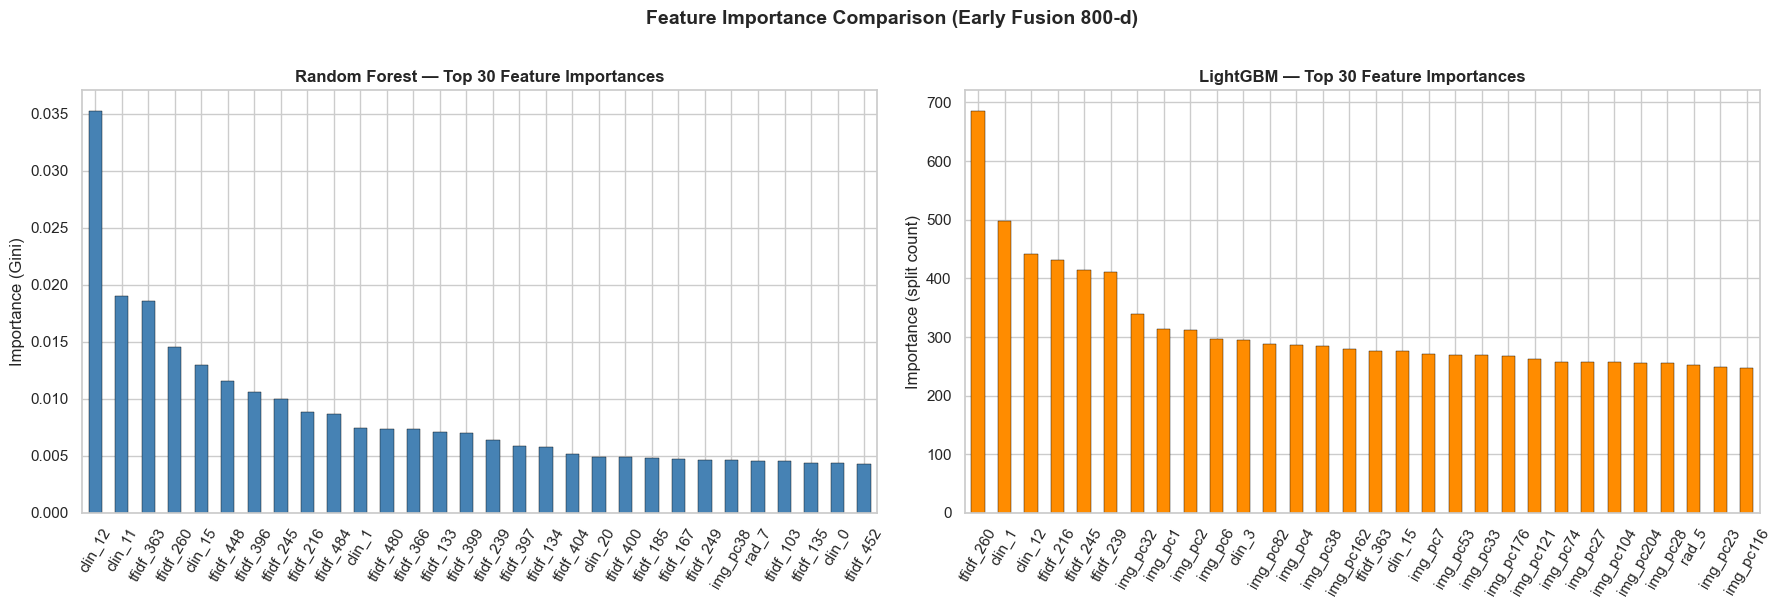


Feature source breakdown in RF Top-30:
  Image       : 1/30
  Radiomics   : 1/30
  Clinical    : 6/30
  Text        : 22/30

Feature source breakdown in LGB Top-30:
  Image       : 20/30
  Radiomics   : 1/30
  Clinical    : 4/30
  Text        : 5/30


In [59]:
# ── 5.3.1  Build feature name list matching the 800-d concatenated vector ──
img_names  = [f'img_pc{i}' for i in range(X_img_train_pca.shape[1])]
rad_names  = [f'rad_{c}' for c in range(X_rad_train.shape[1])]
clin_names = [f'clin_{i}' for i in range(X_clin_train.shape[1])]
text_names = [f'tfidf_{i}' for i in range(X_text_train.shape[1])]
all_feat_names = img_names + rad_names + clin_names + text_names

# ── 5.3.2  Random Forest — Top 30 feature importances ──
rf_imp = pd.Series(rf.feature_importances_, index=all_feat_names).sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

rf_imp.head(30).plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black', linewidth=0.3)
axes[0].set_title('Random Forest — Top 30 Feature Importances', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Importance (Gini)')
axes[0].tick_params(axis='x', rotation=60)

# ── 5.3.3  LightGBM — Top 30 feature importances ──
lgb_imp = pd.Series(lgb_model.feature_importances_, index=all_feat_names).sort_values(ascending=False)
lgb_imp.head(30).plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='black', linewidth=0.3)
axes[1].set_title('LightGBM — Top 30 Feature Importances', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Importance (split count)')
axes[1].tick_params(axis='x', rotation=60)

plt.suptitle('Feature Importance Comparison (Early Fusion 800-d)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# modality breakdown
print('\nFeature source breakdown in RF Top-30:')
top30_rf = rf_imp.head(30).index
for prefix, label in [('img_', 'Image'), ('rad_', 'Radiomics'), ('clin_', 'Clinical'), ('tfidf_', 'Text')]:
    count = sum(1 for f in top30_rf if f.startswith(prefix))
    print(f'  {label:12s}: {count}/30')

print('\nFeature source breakdown in LGB Top-30:')
top30_lgb = lgb_imp.head(30).index
for prefix, label in [('img_', 'Image'), ('rad_', 'Radiomics'), ('clin_', 'Clinical'), ('tfidf_', 'Text')]:
    count = sum(1 for f in top30_lgb if f.startswith(prefix))
    print(f'  {label:12s}: {count}/30')

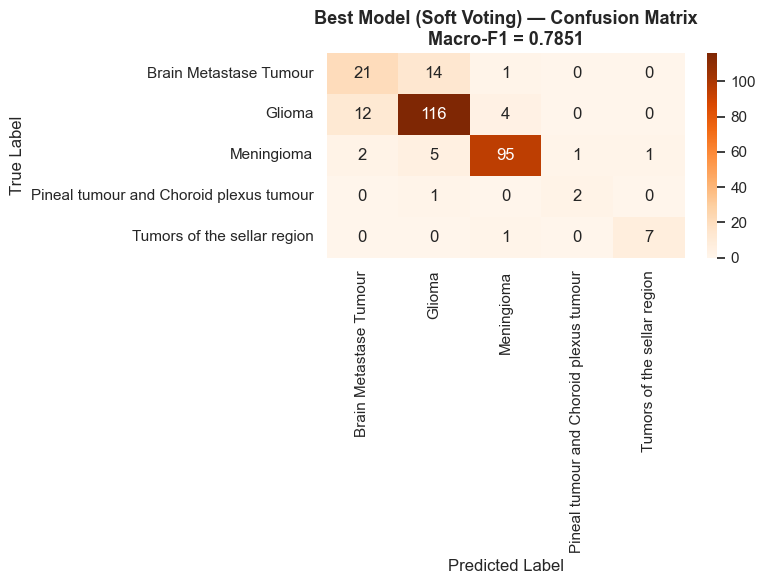


Most confused class pairs (off-diagonal max):
                    Brain Metastase Tumour → predicted as Glioma                         (14 cases)
                                    Glioma → predicted as Brain Metastase Tumour         (12 cases)
                                Meningioma → predicted as Glioma                         (5 cases)


In [60]:
# ── 5.3.4  Confusion matrix of the BEST model (error analysis) ──
best_detail = all_detail[best_name]
cm_best = confusion_matrix(y_val, best_detail['y_pred'])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_, ax=ax)
ax.set_title(f'Best Model ({best_name}) — Confusion Matrix\n'
             f'Macro-F1 = {best_detail["macro_f1"]:.4f}',
             fontsize=13, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(f'\nMost confused class pairs (off-diagonal max):')
np.fill_diagonal(cm_best, 0)
for _ in range(3):
    r, c = np.unravel_index(cm_best.argmax(), cm_best.shape)
    print(f'  {label_encoder.classes_[r]:>40s} → predicted as '
          f'{label_encoder.classes_[c]:<30s} ({cm_best[r, c]} cases)')
    cm_best[r, c] = 0

In [61]:
# --- Strict Scheme A: training-only model selection (repeated CV), val evaluated once ---
from sklearn.base import clone
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import StratifiedKFold


def repeated_cv_with_feature_builder(
    y,
    feature_builder,
    estimator,
    n_splits=5,
    n_repeats=3,
    random_state=SEED,
    fit_kwargs_builder=None,
):
    scores = []
    for rep in range(n_repeats):
        skf_rep = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state + rep,
        )
        for train_idx, eval_idx in skf_rep.split(np.zeros(len(y)), y):
            X_train_fold, X_eval_fold = feature_builder(train_idx, eval_idx)
            scaler_fold = StandardScaler()
            X_train_fold_scaled = scaler_fold.fit_transform(X_train_fold)
            X_eval_fold_scaled = scaler_fold.transform(X_eval_fold)

            fold_model = clone(estimator)
            fit_kwargs = {} if fit_kwargs_builder is None else fit_kwargs_builder(y[train_idx])
            fold_model.fit(X_train_fold_scaled, y[train_idx], **fit_kwargs)
            y_pred_fold = fold_model.predict(X_eval_fold_scaled)
            scores.append(f1_score(y[eval_idx], y_pred_fold, average='macro'))
    return np.array(scores)


strict_candidates = {
    'LR (L2)': {
        'estimator': LogisticRegression(
            max_iter=2000,
            C=1.0,
            class_weight='balanced',
            solver='lbfgs',
            random_state=SEED,
        ),
        'fit_kwargs_builder': None,
    },
    'RF': {
        'estimator': RandomForestClassifier(
            n_estimators=500,
            max_depth=20,
            min_samples_leaf=2,
            class_weight='balanced',
            random_state=SEED,
            n_jobs=-1,
        ),
        'fit_kwargs_builder': None,
    },
    'SVM-RBF': {
        'estimator': SVC(
            C=10,
            kernel='rbf',
            gamma='scale',
            class_weight='balanced',
            probability=True,
            random_state=SEED,
        ),
        'fit_kwargs_builder': None,
    },
    'XGB': {
        'estimator': xgb.XGBClassifier(
            n_estimators=500,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='multi:softprob',
            num_class=len(label_encoder.classes_),
            eval_metric='mlogloss',
            random_state=SEED,
            use_label_encoder=False,
        ),
        'fit_kwargs_builder': lambda y_fold: {'sample_weight': compute_balanced_sample_weights(y_fold)},
    },
    'LGB': {
        'estimator': lgb.LGBMClassifier(
            n_estimators=500,
            max_depth=8,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            num_leaves=63,
            class_weight='balanced',
            random_state=SEED,
            verbose=-1,
            n_jobs=-1,
        ),
        'fit_kwargs_builder': None,
    },
    'MLP': {
        'estimator': MLPClassifier(
            hidden_layer_sizes=(512, 256, 128),
            activation='relu',
            max_iter=500,
            early_stopping=True,
            validation_fraction=0.1,
            batch_size=64,
            learning_rate='adaptive',
            learning_rate_init=0.001,
            random_state=SEED,
        ),
        'fit_kwargs_builder': None,
    },
}

strict_rows = []
for name, spec in strict_candidates.items():
    scores = repeated_cv_with_feature_builder(
        y_train,
        build_early_fusion_fold,
        spec['estimator'],
        n_splits=5,
        n_repeats=3,
        random_state=SEED,
        fit_kwargs_builder=spec['fit_kwargs_builder'],
    )
    strict_rows.append({
        'model': name,
        'cv_mean': float(scores.mean()),
        'cv_std': float(scores.std()),
        'cv_n': int(len(scores)),
    })

strict_df = pd.DataFrame(strict_rows).sort_values('cv_mean', ascending=False).reset_index(drop=True)
print('\nSTRICT SCHEME A (selection only by repeated CV on train)')
print(strict_df.to_string(index=False, formatters={'cv_mean': '{:.4f}'.format, 'cv_std': '{:.4f}'.format}))

strict_cv_selected_name = strict_df.iloc[0]['model']
strict_cv_selected_spec = strict_candidates[strict_cv_selected_name]

strict_cv_selected_scaler = StandardScaler()
X_train_scheme_a = strict_cv_selected_scaler.fit_transform(X_train_all)
X_val_scheme_a = strict_cv_selected_scaler.transform(X_val_all)
X_test_scheme_a = strict_cv_selected_scaler.transform(X_test_all)

strict_cv_selected_model = clone(strict_cv_selected_spec['estimator'])
strict_fit_kwargs = {} if strict_cv_selected_spec['fit_kwargs_builder'] is None else strict_cv_selected_spec['fit_kwargs_builder'](y_train)
strict_cv_selected_model.fit(X_train_scheme_a, y_train, **strict_fit_kwargs)

# Val is evaluated once after model selection is done.
y_val_scheme_a = strict_cv_selected_model.predict(X_val_scheme_a)
val_macro_scheme_a = f1_score(y_val, y_val_scheme_a, average='macro')
val_weighted_scheme_a = f1_score(y_val, y_val_scheme_a, average='weighted')
val_acc_scheme_a = accuracy_score(y_val, y_val_scheme_a)

print(f"\nSelected by repeated CV: {strict_cv_selected_name}")
print(f"One-shot val metrics -> Macro-F1: {val_macro_scheme_a:.4f} | Weighted-F1: {val_weighted_scheme_a:.4f} | Acc: {val_acc_scheme_a:.4f}")

all_detail[f'StrictCV:: {strict_cv_selected_name}'] = {
    'macro_f1': float(val_macro_scheme_a),
    'weighted_f1': float(val_weighted_scheme_a),
    'accuracy': float(val_acc_scheme_a),
    'cv_mean': float(strict_df.iloc[0]['cv_mean']),
    'cv_std': float(strict_df.iloc[0]['cv_std']),
    'y_pred': y_val_scheme_a,
    'model': strict_cv_selected_model,
}

globals()['strict_cv_selected_name'] = strict_cv_selected_name
globals()['strict_cv_selected_model'] = strict_cv_selected_model
globals()['strict_cv_selected_scaler'] = strict_cv_selected_scaler
globals()['strict_cv_selected_test_matrix'] = X_test_scheme_a


STRICT SCHEME A (selection only by repeated CV on train)
  model cv_mean cv_std  cv_n
LR (L2)  0.7031 0.0392    15
SVM-RBF  0.6980 0.0496    15
    MLP  0.6899 0.0455    15
    XGB  0.6438 0.0373    15
    LGB  0.6377 0.0417    15
     RF  0.5067 0.0439    15

Selected by repeated CV: LR (L2)
One-shot val metrics -> Macro-F1: 0.7039 | Weighted-F1: 0.7981 | Acc: 0.7915


## 5.4 Additional Optimization: LR + Soft Voting

This section adds dedicated optimization for:
- `LR (L2)`: CV search over `C`, `class_weight`, and `solver`
- `Soft Voting`: search over estimator subsets, voting weights, and probability calibration settings

Selection is still based on **CV Macro-F1**; validation metrics are reported as reference.

In [63]:
# --- 5.4.1 Dedicated LR optimization (C / class_weight / solver) ---
from itertools import product
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV


if 'repeated_cv_with_feature_builder' not in globals():
    def repeated_cv_with_feature_builder(
        y,
        feature_builder,
        estimator,
        n_splits=5,
        n_repeats=3,
        random_state=SEED,
        fit_kwargs_builder=None,
    ):
        scores = []
        y_np = np.asarray(y)
        for rep in range(n_repeats):
            cv = StratifiedKFold(
                n_splits=n_splits,
                shuffle=True,
                random_state=random_state + rep,
            )
            for tr_idx, ev_idx in cv.split(np.zeros(len(y_np)), y_np):
                X_tr_fold, X_ev_fold = feature_builder(tr_idx, ev_idx)
                est_fold = clone(estimator)
                fit_kwargs = {} if fit_kwargs_builder is None else fit_kwargs_builder(y_np[tr_idx])
                est_fold.fit(X_tr_fold, y_np[tr_idx], **fit_kwargs)
                y_pred_fold = est_fold.predict(X_ev_fold)
                scores.append(f1_score(y_np[ev_idx], y_pred_fold, average='macro'))
        return np.asarray(scores)


lr_search_rows = []
lr_candidates = []
for C, class_weight, solver in product(
    [0.03, 0.1, 0.3, 1.0, 3.0, 10.0],
    [None, 'balanced'],
    ['lbfgs', 'liblinear', 'saga'],
):
    lr_est = LogisticRegression(
        penalty='l2',
        C=C,
        class_weight=class_weight,
        solver=solver,
        max_iter=4000,
        random_state=SEED,
    )
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', lr_est),
    ])
    scores = repeated_cv_with_feature_builder(
        y_train,
        build_early_fusion_fold,
        pipe,
        n_splits=5,
        n_repeats=3,
        random_state=SEED,
    )
    lr_candidates.append((pipe, C, class_weight, solver, scores))
    lr_search_rows.append({
        'C': C,
        'class_weight': class_weight,
        'solver': solver,
        'cv_mean': float(scores.mean()),
        'cv_std': float(scores.std()),
    })

lr_search_df = pd.DataFrame(lr_search_rows).sort_values('cv_mean', ascending=False).reset_index(drop=True)
print('\nLR (L2) CV search (sorted by CV Macro-F1):')
print(lr_search_df.head(12).to_string(index=False, formatters={'cv_mean': '{:.4f}'.format, 'cv_std': '{:.4f}'.format}))

best_lr_row = lr_search_df.iloc[0]
best_lr_class_weight = best_lr_row['class_weight']
if pd.isna(best_lr_class_weight):
    best_lr_class_weight = None

best_lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        penalty='l2',
        C=float(best_lr_row['C']),
        class_weight=best_lr_class_weight,
        solver=str(best_lr_row['solver']),
        max_iter=4000,
        random_state=SEED,
    )),
])
best_lr_pipe.fit(X_train_all, y_train)

lr_tuned_detail = evaluate_model(
    best_lr_pipe,
    X_val_all,
    y_val,
    name='LR (L2) Tuned',
    run_cv=False,
)
lr_tuned_name = (
    f"LR (L2) (Tuned: C={best_lr_row['C']}, cw={best_lr_row['class_weight']}, solver={best_lr_row['solver']})"
)
lr_tuned_detail.update({
    'cv_mean': float(best_lr_row['cv_mean']),
    'cv_std': float(best_lr_row['cv_std']),
    'model': best_lr_pipe,
})

all_detail[lr_tuned_name] = lr_tuned_detail
early_results[lr_tuned_name] = lr_tuned_detail['macro_f1']

globals()['lr_tuned_name'] = lr_tuned_name
globals()['lr_tuned_model'] = best_lr_pipe

tuned_test_matrices = globals().get('tuned_test_matrices', {})
tuned_test_matrices[lr_tuned_name] = X_test_all
globals()['tuned_test_matrices'] = tuned_test_matrices

print(f"\nBest LR tuned config: {lr_tuned_name}")
print(f"  CV Macro-F1 = {lr_tuned_detail['cv_mean']:.4f}±{lr_tuned_detail['cv_std']:.4f}")
print(f"  Val Macro-F1 = {lr_tuned_detail['macro_f1']:.4f}")


# --- 5.4.2 Dedicated Soft Voting optimization ---
def make_base_estimators_for_voting():
    return {
        'lr': LogisticRegression(
            max_iter=4000,
            C=1.0,
            class_weight='balanced',
            solver='lbfgs',
            random_state=SEED,
        ),
        'svm': SVC(
            C=10,
            kernel='rbf',
            gamma='scale',
            class_weight='balanced',
            probability=True,
            random_state=SEED,
        ),
        'xgb': xgb.XGBClassifier(
            n_estimators=500,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='multi:softprob',
            num_class=len(label_encoder.classes_),
            eval_metric='mlogloss',
            random_state=SEED,
            use_label_encoder=False,
        ),
        'lgb': lgb.LGBMClassifier(
            n_estimators=500,
            max_depth=8,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            num_leaves=63,
            class_weight='balanced',
            random_state=SEED,
            verbose=-1,
            n_jobs=-1,
        ),
        'rf': RandomForestClassifier(
            n_estimators=500,
            max_depth=20,
            min_samples_leaf=2,
            class_weight='balanced',
            random_state=SEED,
            n_jobs=-1,
        ),
    }


def build_soft_voter(subset_names, weights, calibration='none'):
    base = make_base_estimators_for_voting()
    ests = []
    for nm in subset_names:
        est = clone(base[nm])

        if calibration == 'svm_sigmoid' and nm == 'svm':
            svm_raw = SVC(
                C=10,
                kernel='rbf',
                gamma='scale',
                class_weight='balanced',
                probability=False,
                random_state=SEED,
            )
            est = CalibratedClassifierCV(estimator=svm_raw, method='sigmoid', cv=3)
        elif calibration == 'svm_isotonic' and nm == 'svm':
            svm_raw = SVC(
                C=10,
                kernel='rbf',
                gamma='scale',
                class_weight='balanced',
                probability=False,
                random_state=SEED,
            )
            est = CalibratedClassifierCV(estimator=svm_raw, method='isotonic', cv=3)
        elif calibration == 'all_sigmoid':
            if nm == 'svm':
                svm_raw = SVC(
                    C=10,
                    kernel='rbf',
                    gamma='scale',
                    class_weight='balanced',
                    probability=False,
                    random_state=SEED,
                )
                est = CalibratedClassifierCV(estimator=svm_raw, method='sigmoid', cv=3)
            else:
                est = CalibratedClassifierCV(estimator=est, method='sigmoid', cv=3)

        ests.append((nm, est))

    voter = VotingClassifier(estimators=ests, voting='soft', weights=weights)
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', voter),
    ])
    return pipe


def generate_weight_candidates(k):
    cands = [tuple([1] * k)]
    cands.append(tuple(range(k, 0, -1)))
    for i in range(k):
        up = [1] * k
        up[i] = 2
        cands.append(tuple(up))
        up3 = [1] * k
        up3[i] = 3
        cands.append(tuple(up3))
    unique = []
    seen = set()
    for w in cands:
        if w not in seen:
            seen.add(w)
            unique.append(w)
    return unique


# Candidate subsets = keep complementary strong learners rather than always using all models.
subset_candidates = [
    ('svm', 'xgb', 'lgb', 'lr'),
    ('svm', 'xgb', 'lr'),
    ('svm', 'lgb', 'lr'),
    ('xgb', 'lgb', 'lr'),
    ('svm', 'rf', 'lr'),
]
calibration_candidates = ['none', 'svm_sigmoid', 'svm_isotonic', 'all_sigmoid']


# Stage A: quick validation screening
soft_screen_rows = []
for subset in subset_candidates:
    for weights in generate_weight_candidates(len(subset)):
        for calib in calibration_candidates:
            model = build_soft_voter(subset, weights, calibration=calib)
            model.fit(X_train_all, y_train)
            y_val_pred = model.predict(X_val_all)
            val_macro = f1_score(y_val, y_val_pred, average='macro')
            soft_screen_rows.append({
                'subset': '+'.join(subset),
                'weights': weights,
                'calibration': calib,
                'val_macro_f1': float(val_macro),
            })

soft_screen_df = pd.DataFrame(soft_screen_rows).sort_values('val_macro_f1', ascending=False).reset_index(drop=True)
print('\nSoft Voting quick screening (top-12 by Val Macro-F1):')
print(soft_screen_df.head(12).to_string(index=False, formatters={'val_macro_f1': '{:.4f}'.format}))


# Stage B: repeated CV on top candidates
soft_cv_rows = []
soft_top_n = min(6, len(soft_screen_df))
for i in range(soft_top_n):
    row = soft_screen_df.iloc[i]
    subset = tuple(row['subset'].split('+'))
    weights = tuple(int(w) for w in row['weights'])
    calib = row['calibration']

    model = build_soft_voter(subset, weights, calibration=calib)
    scores = repeated_cv_with_feature_builder(
        y_train,
        build_early_fusion_fold,
        model,
        n_splits=5,
        n_repeats=3,
        random_state=SEED,
    )
    soft_cv_rows.append({
        'subset': row['subset'],
        'weights': weights,
        'calibration': calib,
        'cv_mean': float(scores.mean()),
        'cv_std': float(scores.std()),
        'val_macro_f1_screen': float(row['val_macro_f1']),
    })

soft_cv_df = pd.DataFrame(soft_cv_rows).sort_values('cv_mean', ascending=False).reset_index(drop=True)
print('\nSoft Voting CV refinement (top by CV Macro-F1):')
print(soft_cv_df.to_string(index=False, formatters={
    'cv_mean': '{:.4f}'.format,
    'cv_std': '{:.4f}'.format,
    'val_macro_f1_screen': '{:.4f}'.format,
}))

best_soft_row = soft_cv_df.iloc[0]
best_subset = tuple(best_soft_row['subset'].split('+'))
best_weights = tuple(int(w) for w in best_soft_row['weights'])
best_calib = best_soft_row['calibration']

best_soft_model = build_soft_voter(best_subset, best_weights, calibration=best_calib)
best_soft_model.fit(X_train_all, y_train)

soft_tuned_detail = evaluate_model(
    best_soft_model,
    X_val_all,
    y_val,
    name='Soft Voting Tuned',
    run_cv=False,
)

soft_tuned_name = (
    f"Soft Voting (Tuned: subset={'+'.join(best_subset)}, weights={list(best_weights)}, calib={best_calib})"
)
soft_tuned_detail.update({
    'cv_mean': float(best_soft_row['cv_mean']),
    'cv_std': float(best_soft_row['cv_std']),
    'model': best_soft_model,
})

all_detail[soft_tuned_name] = soft_tuned_detail
late_results[soft_tuned_name] = soft_tuned_detail['macro_f1']

globals()['soft_voting_tuned_name'] = soft_tuned_name
globals()['soft_voting_tuned_model'] = best_soft_model

tuned_test_matrices = globals().get('tuned_test_matrices', {})
tuned_test_matrices[soft_tuned_name] = X_test_all
globals()['tuned_test_matrices'] = tuned_test_matrices

print(f"\nBest Soft Voting tuned config: {soft_tuned_name}")
print(f"  CV Macro-F1 = {soft_tuned_detail['cv_mean']:.4f}±{soft_tuned_detail['cv_std']:.4f}")
print(f"  Val Macro-F1 = {soft_tuned_detail['macro_f1']:.4f}")


LR (L2) CV search (sorted by CV Macro-F1):
   C class_weight    solver cv_mean cv_std
0.03     balanced     lbfgs  0.7279 0.0406
0.03     balanced      saga  0.7260 0.0448
0.10     balanced     lbfgs  0.7218 0.0407
0.10     balanced      saga  0.7201 0.0398
0.03     balanced liblinear  0.7146 0.0591
0.10     balanced liblinear  0.7128 0.0570
0.30     balanced     lbfgs  0.7082 0.0430
0.03         None      saga  0.7065 0.0454
0.03         None liblinear  0.7054 0.0605
1.00     balanced     lbfgs  0.7029 0.0389
0.10         None      saga  0.7025 0.0448
0.30     balanced      saga  0.7019 0.0347

  LR (L2) Tuned
  [Val] Macro-F1 = 0.7033  |  Accuracy = 0.8021  |  Weighted-F1 = 0.8085

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.5098    0.7222    0.5977        36
                                 Glioma     0.8707    0.7652    0.8145       132
                        

## 6. Submissions

In [79]:
# --- Submissions for optimized SVM-RBF / Soft Voting / LR(L2) ---
# This cell prefers tuned models (if available) and falls back to the baseline counterparts.

from pathlib import Path


def _build_submission(model, X_test_matrix, out_name):
    y_test_pred = model.predict(X_test_matrix)
    sub = pd.DataFrame({
        'case_id': [int(c) for c in test_ids],
        'Overall_class': label_encoder.inverse_transform(y_test_pred),
    })

    sample_sub = pd.read_csv(TEST_ROOT / 'sample_submission.csv')
    sub = sub.set_index('case_id').loc[sample_sub['case_id']].reset_index()
    assert len(sub) == len(sample_sub), (
        f'Got {len(sub)} rows but sample_submission has {len(sample_sub)} rows.'
    )

    out_path = Path.cwd() / out_name
    sub.to_csv(out_path, index=False)
    print(f'Wrote: {out_path.resolve()} ({len(sub)} rows)')


# Collect available trained models
model_map = {
    'LR (L2)': globals().get('lr', None),
    'SVM-RBF': globals().get('svm', None),
    'Soft Voting': globals().get('voting_clf', None),
}

for detail_store_name in ['all_detail', 'early_detail', 'late_detail']:
    detail_store = globals().get(detail_store_name, {})
    if isinstance(detail_store, dict):
        for nm, detail in detail_store.items():
            if isinstance(detail, dict) and ('model' in detail):
                model_map[nm] = detail['model']

# Priority: optimized/tuned name -> baseline name
target_candidates = {
    'svm_rbf': [globals().get('svm_rbf_optimized_model_name'), 'SVM-RBF'],
    'soft_voting': [globals().get('soft_voting_tuned_name'), 'Soft Voting'],
    'lr_l2': [globals().get('lr_tuned_name'), 'LR (L2)'],
}

optimized_test_matrices = globals().get('optimized_test_matrices', {})
tuned_test_matrices = globals().get('tuned_test_matrices', {})
default_test_matrices = {
    'LR (L2)': globals().get('X_test_scaled', None),
    'SVM-RBF': globals().get('X_test_scaled', None),
    'Soft Voting': globals().get('X_test_scaled', None),
}

resolved = {}
for key, name_candidates in target_candidates.items():
    picked_name = None
    for nm in name_candidates:
        if nm is not None and nm in model_map and model_map[nm] is not None:
            picked_name = nm
            break
    if picked_name is None:
        raise KeyError(f'No available model found for target: {key}. Please rerun training cells first.')

    X_test_for_model = optimized_test_matrices.get(
        picked_name,
        tuned_test_matrices.get(
            picked_name,
            default_test_matrices.get(picked_name, globals().get('X_test_all', globals().get('X_test_scaled'))),
        ),
    )

    if X_test_for_model is None:
        raise KeyError(f'No available test matrix found for model: {picked_name}.')

    resolved[key] = (picked_name, model_map[picked_name], X_test_for_model)

print('Chosen models for export:')
for key, (name, _, _) in resolved.items():
    print(f'  - {key}: {name}')

_build_submission(resolved['svm_rbf'][1], resolved['svm_rbf'][2], 'submission_svm_rbf_optimized.csv')
_build_submission(resolved['soft_voting'][1], resolved['soft_voting'][2], 'submission_soft_voting_tuned.csv')
_build_submission(resolved['lr_l2'][1], resolved['lr_l2'][2], 'submission_lr_l2_tuned.csv')

Chosen models for export:
  - svm_rbf: SVM-RBF (Optimized 4.1: MI top-256)
  - soft_voting: Soft Voting (Tuned: subset=svm+xgb+lgb+lr, weights=[4, 3, 2, 1], calib=none)
  - lr_l2: LR (L2) (Tuned: C=0.03, cw=balanced, solver=lbfgs)
Wrote: /Users/qinzilan/Desktop/3612/submission_svm_rbf_optimized.csv (378 rows)
Wrote: /Users/qinzilan/Desktop/3612/submission_soft_voting_tuned.csv (378 rows)
Wrote: /Users/qinzilan/Desktop/3612/submission_lr_l2_tuned.csv (378 rows)


On the Kaggle leaderboard, the highest-scoring model we used is soft_voting: Soft Voting (Tuned: subset = SVM + XGB + LGB + LR, weights = [4, 3, 2, 1], calib = none).